In [37]:
import warnings
warnings.filterwarnings("ignore")

In [38]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [39]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base

In [40]:
project_id = 'loft-dl-datascience'

query = '''
WITH
first_defaults AS (
  SELECT
    contract_id,
    DATE(MIN(pendency_created_at)) AS first_comunicacao_date,
    DATE(MIN(pendency_at)) AS first_competencia_date,
    DATE(MIN(payment_at)) AS first_payment_date
  FROM `loft-dl-fintech.cp_gold.watchlist_fact`
  WHERE pendency_type IN ('Inadimplência')
  GROUP BY contract_id
),

tb_leads as(
  SELECT
    rf.contract_id,
    date(cf.requested_at) as requested_at,
    cf.tipo,
    cf.tipo_contrato,
    cf.rule,
    cf.bureau_nm,
    cf.modeloBlend,
    rf.approved_products,
    case when '32' in unnest(json_value_array(rf.approved_products)) then 1 else 0 end as flag_pop32,
    rd.product_nm,
    case when cf.modeloBlend = 'BLEND_REGRESSAO_2026' and cf.bureau_nm in ('BLEND_REGRESSAO_2026', 'BVS_CUSTOM', 'HVA3') then 'BLEND2'
        when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BLEND3_3', 'BLEND3_4', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') and cf.bureau_nm in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        else 'Outros' end as bureau_nm_ajust,
    case when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BVS_CUSTOM', 'HVA4') then 1
        when cf.bureau_nm in ('BVS_CUSTOM_V2', 'HFT1') then 1
        else 0 end as is_fallback, -- apenas blend3 e blend4
    i.id_imobiliaria,
    i.id_cidade_ibge,
    i.cidade as imovel_cidade,
    i.uf as imovel_uf,
    ad.segmentacao as agency_segmentacao,
    rd.lead_elegivel,
    rd.proposta_iniciada,
    rd.proposta_enviada,
    rd.proposta_aprovada,
    rd.proposta_ativada,
    rd.is_activeted,
    rf.activated_at,
    rd.aprovado_motor_mesa,
    coalesce(cf.rating_score_ds, '-1') as rating_score_ds,
    case when coalesce(cf.qtd_proponentes, -1) <= 1 then 1 else 0 end as is_single_proponent,
    ca.blend_regressao_predict_nr,

    COALESCE(rd.is_activeted, cf.is_activeted) AS is_activeted,

    DATE_DIFF(
      DATE_TRUNC(DATE(CURRENT_DATE()), MONTH),
      DATE_TRUNC(COALESCE(DATE(rf.activated_at), DATE(cf.requested_at)), MONTH),
      MONTH
    ) AS time2requested,

    CASE
      WHEN fd.first_competencia_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.first_competencia_date), MONTH),
        DATE_TRUNC(DATE(rf.activated_at), MONTH),
        MONTH
      )
    END AS time2def_pc,
    CASE
      WHEN fd.first_comunicacao_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.first_comunicacao_date), MONTH),
        DATE_TRUNC(DATE(rf.activated_at), MONTH),
        MONTH
      )
    END AS time2def_pcc,

    CASE
      WHEN fd.first_payment_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE_TRUNC(DATE(fd.first_payment_date), MONTH),
        DATE_TRUNC(DATE(rf.activated_at), MONTH),
        MONTH
      )
    END AS time2def_pd,

    fd.first_comunicacao_date,
    fd.first_competencia_date,
    fd.first_payment_date

  from loft-dl-fintech.cp_gold.requests_fact as rf
  left join loft-dl-fintech.cp_gold.requests_dim AS rd
    on rf.contract_id = rd.contract_id
  left join loft-dl-fintech.cp_gold.credit_fact as cf
    on rf.contract_id = cf.contract_id
  left join loft-dl-fintech.cp_silver.int_credit_analyses as ca
    on rf.contract_id = ca.contract_id
  left join loft-dl-fintech.bronze_credpago_enriched.imovel as i
    on rf.contract_id = i.id
  left join loft-dl-fintech.cp_gold.agency_dim as ad
    on rd.agency_id = ad.agency_id
  left join first_defaults as fd
    on rf.contract_id = fd.contract_id
  where cf.tipo_contrato = 'PF' and
    date(cf.requested_at) >= date('2024-01-01') and
    date(cf.requested_at) < date(current_date())
), 

leads_e_defaults_mob AS (
  SELECT
    *,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 4 AND time2def_pc <= 2 THEN 1
      WHEN time2requested >= 4 THEN 0
      ELSE NULL
    END AS pc_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 5 AND time2def_pc <= 3 THEN 1
      WHEN time2requested >= 5 THEN 0
      ELSE NULL
    END AS pc_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 6 AND time2def_pc <= 4 THEN 1
      WHEN time2requested >= 6 THEN 0
      ELSE NULL
    END AS pc_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 2 AND time2def_pcc <= 2 THEN 1
      WHEN time2requested >= 2 THEN 0
      ELSE NULL
    END AS pcc_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 3 AND time2def_pcc <= 3 THEN 1
      WHEN time2requested >= 3 THEN 0
      ELSE NULL
    END AS pcc_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 4 AND time2def_pcc <= 4 THEN 1
      WHEN time2requested >= 4 THEN 0
      ELSE NULL
    END AS pcc_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 2 AND time2def_pd <= 2 THEN 1
      WHEN time2requested >= 2 THEN 0
      ELSE NULL
    END AS pd_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 3 AND time2def_pd <= 3 THEN 1
      WHEN time2requested >= 3 THEN 0
      ELSE NULL
    END AS pd_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 4 AND time2def_pd <= 4 THEN 1
      WHEN time2requested >= 4 THEN 0
      ELSE NULL
    END AS pd_4m,
    FROM tb_leads
)

SELECT *
FROM leads_e_defaults_mob
'''

In [41]:
# df_sim_ctr = pd.read_gbq(query, project_id=project_id)
# df_sim_ctr

In [42]:
# df_sim_ctr.to_parquet(ANALYTICS_DIR / "df_sim_ctr_pc4m.parquet")

In [43]:
df_sim_ctr = pd.read_parquet(ANALYTICS_DIR / "df_sim_ctr_pc4m.parquet")
df_sim_ctr["safra"] = pd.to_datetime(df_sim_ctr["requested_at"]).dt.to_period("M").astype(str)

In [44]:
df_sim_ctr.groupby(["safra", "bureau_nm_ajust"], dropna=False).size()

safra    bureau_nm_ajust
2024-06  Outros              46915
2024-07  BLEND3                  1
         Outros              52169
2024-08  BLEND2                  1
         BLEND3                  3
         Outros              51299
2024-09  BLEND2                  1
         Outros              48000
2024-10  BLEND2                  1
         Outros              54600
2024-11  Outros              48154
2024-12  BLEND2                  1
         Outros              48391
2025-01  Outros             112496
2025-02  BLEND2                  1
         Outros             113257
2025-03  Outros              98846
2025-04  Outros              98656
2025-05  BLEND3                  1
         Outros             107639
2025-06  BLEND3                  2
         Outros             123920
2025-07  BLEND3                  1
         Outros             142580
2025-08  Outros             128336
2025-09  Outros             137721
2025-10  BLEND2                  1
         Outros             13

In [45]:
df_sim_ctr[df_sim_ctr["is_activeted"] == True].groupby(["safra", "bureau_nm_ajust"], dropna=False).size()

safra    bureau_nm_ajust
2024-06  Outros             14389
2024-07  Outros             16245
2024-08  BLEND3                 2
         Outros             15419
2024-09  Outros             14718
2024-10  BLEND2                 1
         Outros             16595
2024-11  Outros             15030
2024-12  BLEND2                 1
         Outros             12460
2025-01  Outros             20053
2025-02  Outros             17728
2025-03  Outros             17197
2025-04  Outros             16314
2025-05  Outros             17061
2025-06  BLEND3                 1
         Outros             19026
2025-07  BLEND3                 1
         Outros             20029
2025-08  Outros             18508
2025-09  Outros             18255
2025-10  BLEND2                 1
         Outros             17179
2025-11  BLEND2                 1
         Outros             14654
2025-12  BLEND2                13
         Outros             12086
2026-01  BLEND2              2116
         Outros        

In [46]:
df_sim_ctr[df_sim_ctr["id_cidade_ibge"].isna()]

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,pc_2m,pc_3m,pc_4m,pcc_2m,pcc_3m,pcc_4m,pd_2m,pd_3m,pd_4m,safra


## Calcular Janela [-13M, -7M]

In [47]:
summary = (
    df_sim_ctr.groupby("safra", as_index=False)
    .agg(
        n_2_pc2=("pc_2m", "count"),
        pc_2m=("pc_2m", "mean"),
        n_2_pcc2=("pcc_2m", "count"),
        pcc_2m=("pcc_2m", "mean"),
        n_2_pd2=("pd_2m", "count"),
        pd_2m=("pd_2m", "mean"),
        n_3_pc3=("pc_3m", "count"),
        pc_3m=("pc_3m", "mean"),
        n_3_pcc3=("pcc_3m", "count"),
        pcc_3m=("pcc_3m", "mean"),
        n_3_pd3=("pd_3m", "count"),
        pd_3m=("pd_3m", "mean"),
        n_4_pc4=("pc_4m", "count"),
        pc_4m=("pc_4m", "mean"),
        n_4_pcc4=("pcc_4m", "count"),
        pcc_4m=("pcc_4m", "mean"),
        n_4_pd4=("pd_4m", "count"),
        pd_4m=("pd_4m", "mean"),
    )
    .sort_values("safra")
)
summary

,safra,n_2_pc2,pc_2m,n_2_pcc2,pcc_2m,n_2_pd2,pd_2m,n_3_pc3,pc_3m,n_3_pcc3,pcc_3m,n_3_pd3,pd_3m,n_4_pc4,pc_4m,n_4_pcc4,pcc_4m,n_4_pd4,pd_4m
0,2024-06,14389,0.052401,14389,0.037181,14389,0.003127,14389,0.074849,14389,0.060741,14389,0.01251,14389,0.097297,14389,0.084787,14389,0.025019
1,2024-07,16245,0.058049,16245,0.039951,16245,0.003078,16245,0.082733,16245,0.068021,16245,0.013296,16245,0.107479,16245,0.093752,16245,0.026531
2,2024-08,15421,0.060307,15421,0.044485,15421,0.003567,15421,0.085144,15421,0.069516,15421,0.01673,15421,0.108488,15421,0.092601,15421,0.031645
3,2024-09,14718,0.061082,14718,0.043756,14718,0.004145,14718,0.086968,14718,0.069914,14718,0.014948,14718,0.112855,14718,0.0975,14718,0.029827
4,2024-10,16596,0.06357,16596,0.043565,16596,0.003435,16596,0.094842,16596,0.078332,16596,0.017113,16596,0.12262,16596,0.103037,16596,0.033803
5,2024-11,15030,0.061943,15030,0.045243,15030,0.003393,15030,0.092349,15030,0.072056,15030,0.016833,15030,0.120027,15030,0.101663,15030,0.032269
6,2024-12,12461,0.069657,12461,0.048551,12461,0.005939,12461,0.095819,12461,0.078886,12461,0.020544,12461,0.122542,12461,0.106091,12461,0.038681
7,2025-01,20053,0.063183,20053,0.044482,20053,0.00369,20053,0.090809,20053,0.072408,20053,0.01875,20053,0.112801,20053,0.096544,20053,0.036204
8,2025-02,17728,0.06752,17728,0.046931,17728,0.005528,17728,0.094314,17728,0.076151,17728,0.019968,17728,0.11338,17728,0.097247,17728,0.038188
9,2025-03,17197,0.064721,17197,0.04367,17197,0.005117,17197,0.088504,17197,0.068558,17197,0.019131,17197,0.108972,17197,0.093563,17197,0.035762


In [48]:
from pandas.tseries.offsets import MonthBegin

df_sim_ctr["safra_dt"] = pd.to_datetime(df_sim_ctr["safra"] + "-01")

ref_safras = pd.period_range("2026-03", "2026-07", freq="M").astype(str)

rows = []
for ref in ref_safras:
    ref_dt = pd.to_datetime(ref + "-01")
    start = ref_dt + MonthBegin(-13)  # 2026-06 -> 2025-05
    end = ref_dt + MonthBegin(-7)     # 2026-06 -> 2025-11

    mask = (df_sim_ctr["safra_dt"] >= start) & (df_sim_ctr["safra_dt"] <= end)
    window = df_sim_ctr.loc[mask]

    rows.append({
        "safra_ref": ref,
        "window_start": start.strftime("%Y-%m"),
        "window_end": end.strftime("%Y-%m"),
        "n_2_pc2": window["pc_2m"].count(),
        "pc_2m": window["pc_2m"].mean(),
        "n_2_pcc2": window["pcc_2m"].count(),
        "pcc_2m": window["pcc_2m"].mean(),
        "n_2_pd2": window["pd_2m"].count(),
        "pd_2m": window["pd_2m"].mean(),
        "n_3_pc3": window["pc_3m"].count(),
        "pc_3m": window["pc_3m"].mean(),
        "n_3_pcc3": window["pcc_3m"].count(),
        "pcc_3m": window["pcc_3m"].mean(),
        "n_3_pd3": window["pd_3m"].count(),
        "pd_3m": window["pd_3m"].mean(),
        "n_4_pc4": window["pc_4m"].count(),
        "pc_4m": window["pc_4m"].mean(),
        "n_4_pcc4": window["pcc_4m"].count(),
        "pcc_4m": window["pcc_4m"].mean(),
        "n_4_pd4": window["pd_4m"].count(),
        "pd_4m": window["pd_4m"].mean(),
    })

summary_window = pd.DataFrame(rows)
summary_window

,safra_ref,window_start,window_end,n_2_pc2,pc_2m,n_2_pcc2,pcc_2m,n_2_pd2,pd_2m,n_3_pc3,...,n_3_pcc3,pcc_3m,n_3_pd3,pd_3m,n_4_pc4,pc_4m,n_4_pcc4,pcc_4m,n_4_pd4,pd_4m
0,2026-03,2025-02,2025-08,125865,0.057069,125865,0.037469,125865,0.004489,125865,...,125865,0.062313,125865,0.016971,125865,0.100934,125865,0.084885,125865,0.032988
1,2026-04,2025-03,2025-09,126392,0.054996,126392,0.035350,126392,0.004454,126392,...,126392,0.059339,126392,0.016504,126392,0.099041,126392,0.082830,126392,0.032130
2,2026-05,2025-04,2025-10,126375,0.053650,126375,0.033401,126375,0.004376,126375,...,126375,0.058176,126375,0.016158,126375,0.098469,126375,0.081480,126375,0.031850
3,2026-06,2025-05,2025-11,124716,0.053906,124716,0.033516,124716,0.004490,124716,...,124716,0.057972,124716,0.016261,124716,0.099129,124716,0.081938,124716,0.031961
4,2026-07,2025-06,2025-12,119754,0.054245,119754,0.033385,119754,0.004776,119754,...,119754,0.058670,119754,0.016442,119754,0.100539,119754,0.083104,119754,0.033151


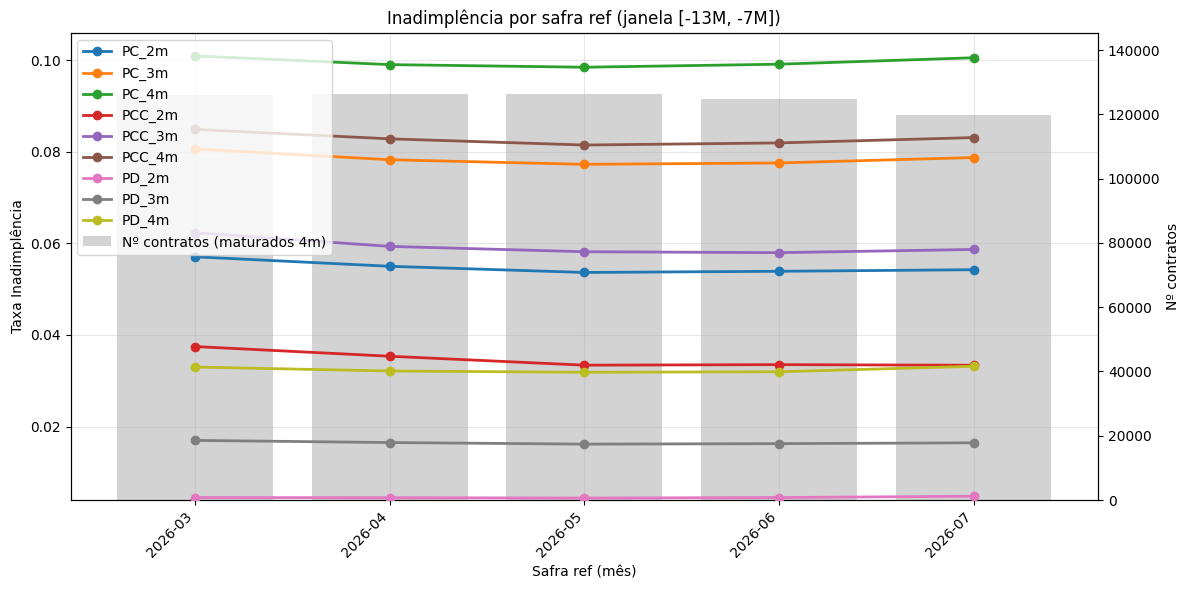

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

# bars in the background
ax2.bar(
    summary_window["safra_ref"],
    summary_window["n_4_pcc4"],
    color="lightgray",
    width=0.8,
    label="Nº contratos (maturados 4m)",
    zorder=1,
)

# lines in front
ax.plot(summary_window["safra_ref"], summary_window["pc_2m"], marker="o", linewidth=2, label="PC_2m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pc_3m"], marker="o", linewidth=2, label="PC_3m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pc_4m"], marker="o", linewidth=2, label="PC_4m", zorder=3)

ax.plot(summary_window["safra_ref"], summary_window["pcc_2m"], marker="o", linewidth=2, label="PCC_2m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pcc_3m"], marker="o", linewidth=2, label="PCC_3m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pcc_4m"], marker="o", linewidth=2, label="PCC_4m", zorder=3)

ax.plot(summary_window["safra_ref"], summary_window["pd_2m"], marker="o", linewidth=2, label="PD_2m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pd_3m"], marker="o", linewidth=2, label="PD_3m", zorder=3)
ax.plot(summary_window["safra_ref"], summary_window["pd_4m"], marker="o", linewidth=2, label="PD_4m", zorder=3)


ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax.set_xlabel("Safra ref (mês)")
ax.set_ylabel("Taxa Inadimplência")
ax2.set_ylabel("Nº contratos")
ax.set_title("Inadimplência por safra ref (janela [-13M, -7M])")
ax.grid(alpha=0.3)

pc_cols = ["pc_2m", "pc_3m", "pc_4m", "pcc_2m", "pcc_3m", "pcc_4m", "pd_2m", "pd_3m", "pd_4m"]
ax.set_ylim(
    max(0, summary_window[pc_cols].min().min() * 0.9),
    summary_window[pc_cols].max().max() * 1.05,
)
ax2.set_ylim(0, summary_window["n_4_pcc4"].max() * 1.15)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

Essa é a inadimplência **geral** na janela de `requested_at`. A seção seguinte recalcula o conceito 100+ no mesmo recorte da query: `activated_at` em `[M-13M, M-7M)`, taxa por cidade/imobiliária e depois percentis / média ponderada.

## Inadimplência — cidades / imobiliárias com mais de 100 contratos

Mesma janela da query (`activated_at` em `[M-13M, M-7M)`), com a **PC4 de monitoramento**:

- janela em **`activated_at`**: `[M-13M, M-7M)` (fim exclusivo)
- conta todos os contratos **ativados** na janela
- entidade entra no grupo se `n_contracts > 100`
- taxa = `pc_4m` (só contratos maduros: `time2requested >= 6`)
- pesos da média ponderada = contratos com `pc_4m` preenchido
- agregação **por entidade** e depois percentis / média / média ponderada

In [50]:
MIN_CONTRACTS = 100

df_act = df_sim_ctr.loc[df_sim_ctr["activated_at"].notna()].copy()
df_act["activated_dt"] = (
    pd.to_datetime(df_act["activated_at"], utc=True)
    .dt.tz_localize(None)
    .dt.to_period("M")
    .dt.to_timestamp()
)


def entity_pc4(window, entity_col):
    stats = (
        window.groupby(entity_col, dropna=True)
        .agg(
            n_ones=("pc_4m", "sum"),
            n_obs=("pc_4m", "count"),
            n_contracts=("contract_id", "nunique"),
            mn_ativacao=("activated_dt", "min"),
            mx_ativacao=("activated_dt", "max"),
            cnt_ativacao=("activated_dt", "nunique"),
        )
        .reset_index()
    )
    stats["pc4"] = np.where(stats["n_obs"] > 0, stats["n_ones"] / stats["n_obs"], np.nan)
    return stats


def pooled_rate(entity_df):
    n_ones = entity_df["n_ones"].sum()
    n_obs = entity_df["n_obs"].sum()
    return (n_ones / n_obs) if n_obs else None


def summarize_entities(entity_df, ref, start, end, entity_type, group):
    n_contracts = entity_df["n_contracts"].sum()
    n_obs = entity_df["n_obs"].sum()
    return {
        "safra_ref": ref,
        "window_start": start.strftime("%Y-%m"),
        "window_end_exclusive": end.strftime("%Y-%m"),
        "entity_type": entity_type,
        "class": group,
        "cnt_entities": int(len(entity_df)),
        "n_contracts": int(n_contracts),
        "n_pc4": int(n_obs),
        "p10_var": entity_df["pc4"].quantile(0.10),
        "p25_var": entity_df["pc4"].quantile(0.25),
        "p50_var": entity_df["pc4"].quantile(0.50),
        "p75_var": entity_df["pc4"].quantile(0.75),
        "p90_var": entity_df["pc4"].quantile(0.90),
        "avg_var": pooled_rate(entity_df),
        "avg_var_ponderada": pooled_rate(entity_df),
        "mn_ativacao": entity_df["mn_ativacao"].min() if len(entity_df) else None,
        "mx_ativacao": entity_df["mx_ativacao"].max() if len(entity_df) else None,
    }


rows_entity = []
for ref in ref_safras:
    ref_dt = pd.to_datetime(ref + "-01")
    start = ref_dt + MonthBegin(-13)
    end = ref_dt + MonthBegin(-7)
    window = df_act.loc[(df_act["activated_dt"] >= start) & (df_act["activated_dt"] < end)]

    for entity_col, entity_type in [("id_cidade_ibge", "city"), ("id_imobiliaria", "agency")]:
        stats = entity_pc4(window, entity_col)
        rows_entity.append(summarize_entities(stats, ref, start, end, entity_type, "geral"))
        over100 = stats[stats["n_contracts"] > MIN_CONTRACTS]
        rows_entity.append(
            summarize_entities(over100, ref, start, end, entity_type, "has_mais_100_contratos")
        )

summary_entity_pc4 = pd.DataFrame(rows_entity)
summary_geral_city = summary_entity_pc4[
    (summary_entity_pc4["entity_type"] == "city") & (summary_entity_pc4["class"] == "geral")
].reset_index(drop=True)
summary_100_city = summary_entity_pc4[
    (summary_entity_pc4["entity_type"] == "city")
    & (summary_entity_pc4["class"] == "has_mais_100_contratos")
].reset_index(drop=True)
summary_geral_agency = summary_entity_pc4[
    (summary_entity_pc4["entity_type"] == "agency") & (summary_entity_pc4["class"] == "geral")
].reset_index(drop=True)
summary_100_agency = summary_entity_pc4[
    (summary_entity_pc4["entity_type"] == "agency")
    & (summary_entity_pc4["class"] == "has_mais_100_contratos")
].reset_index(drop=True)

print("Cidades — geral e 100+")
pd.concat([summary_geral_city, summary_100_city], ignore_index=True).sort_values(
    ["safra_ref", "class"]
)

Cidades — geral e 100+


,safra_ref,window_start,window_end_exclusive,entity_type,class,cnt_entities,n_contracts,n_pc4,p10_var,p25_var,p50_var,p75_var,p90_var,avg_var,avg_var_ponderada,mn_ativacao,mx_ativacao
0,2026-03,2025-02,2025-08,city,geral,870,106102,106102,0.000000,0.000000,0.054259,0.111111,0.166800,0.101101,0.101101,2025-02-01,2025-07-01
5,2026-03,2025-02,2025-08,city,has_mais_100_contratos,188,94261,94261,0.055829,0.071986,0.095842,0.127337,0.155975,0.103309,0.103309,2025-02-01,2025-07-01
1,2026-04,2025-03,2025-09,city,geral,864,107296,107296,0.000000,0.000000,0.050000,0.108108,0.166667,0.098755,0.098755,2025-03-01,2025-08-01
6,2026-04,2025-03,2025-09,city,has_mais_100_contratos,193,95694,95694,0.052602,0.069474,0.093023,0.121495,0.152095,0.100989,0.100989,2025-03-01,2025-08-01
2,2026-05,2025-04,2025-10,city,geral,870,108938,108938,0.000000,0.000000,0.050000,0.103405,0.166667,0.097744,0.097744,2025-04-01,2025-09-01
7,2026-05,2025-04,2025-10,city,has_mais_100_contratos,192,96863,96863,0.052236,0.068738,0.090909,0.120761,0.147295,0.100203,0.100203,2025-04-01,2025-09-01
3,2026-06,2025-05,2025-11,city,geral,877,110055,110055,0.000000,0.000000,0.045455,0.096774,0.166667,0.097388,0.097388,2025-05-01,2025-10-01
8,2026-06,2025-05,2025-11,city,has_mais_100_contratos,195,98001,98001,0.052791,0.068665,0.091743,0.120905,0.147961,0.100009,0.100009,2025-05-01,2025-10-01
4,2026-07,2025-06,2025-12,city,geral,876,107801,107801,0.000000,0.000000,0.047932,0.100000,0.166667,0.098459,0.098459,2025-06-01,2025-11-01
9,2026-07,2025-06,2025-12,city,has_mais_100_contratos,194,95766,95766,0.057741,0.071705,0.089770,0.120477,0.148475,0.101257,0.101257,2025-06-01,2025-11-01


## Imobiliárias — geral vs mais de 100 contratos

In [51]:
print("Imobiliárias — geral e 100+")
pd.concat([summary_geral_agency, summary_100_agency], ignore_index=True).sort_values(
    ["safra_ref", "class"]
)

Imobiliárias — geral e 100+


,safra_ref,window_start,window_end_exclusive,entity_type,class,cnt_entities,n_contracts,n_pc4,p10_var,p25_var,p50_var,p75_var,p90_var,avg_var,avg_var_ponderada,mn_ativacao,mx_ativacao
0,2026-03,2025-02,2025-08,agency,geral,8006,106102,106102,0.000000,0.000000,0.000000,0.095238,0.222222,0.101101,0.101101,2025-02-01,2025-07-01
5,2026-03,2025-02,2025-08,agency,has_mais_100_contratos,146,28225,28225,0.053709,0.085382,0.120633,0.156643,0.201504,0.124110,0.124110,2025-02-01,2025-07-01
1,2026-04,2025-03,2025-09,agency,geral,8059,107296,107296,0.000000,0.000000,0.000000,0.090909,0.202411,0.098755,0.098755,2025-03-01,2025-08-01
6,2026-04,2025-03,2025-09,agency,has_mais_100_contratos,154,29656,29656,0.051033,0.080938,0.117361,0.163491,0.205811,0.124865,0.124865,2025-03-01,2025-08-01
2,2026-05,2025-04,2025-10,agency,geral,8137,108938,108938,0.000000,0.000000,0.000000,0.086957,0.200000,0.097744,0.097744,2025-04-01,2025-09-01
7,2026-05,2025-04,2025-10,agency,has_mais_100_contratos,150,29724,29724,0.049394,0.079893,0.116595,0.162990,0.212045,0.125690,0.125690,2025-04-01,2025-09-01
3,2026-06,2025-05,2025-11,agency,geral,8104,110055,110055,0.000000,0.000000,0.000000,0.088811,0.211643,0.097388,0.097388,2025-05-01,2025-10-01
8,2026-06,2025-05,2025-11,agency,has_mais_100_contratos,151,30141,30141,0.053097,0.081357,0.112000,0.158303,0.215139,0.124316,0.124316,2025-05-01,2025-10-01
4,2026-07,2025-06,2025-12,agency,geral,8037,107801,107801,0.000000,0.000000,0.000000,0.090909,0.200000,0.098459,0.098459,2025-06-01,2025-11-01
9,2026-07,2025-06,2025-12,agency,has_mais_100_contratos,143,28869,28869,0.060242,0.080431,0.111940,0.161035,0.222820,0.126606,0.126606,2025-06-01,2025-11-01


## Comparação geral vs 100+

In [52]:
compare_pc4 = (
    summary_geral_city[
        ["safra_ref", "window_start", "window_end_exclusive", "cnt_entities", "n_contracts", "avg_var", "avg_var_ponderada"]
    ]
    .rename(columns={
        "cnt_entities": "n_cities_geral",
        "n_contracts": "n_contracts_city_geral",
        "avg_var": "avg_city_geral",
        "avg_var_ponderada": "pc4_ponderada_city_geral",
    })
    .merge(
        summary_100_city[["safra_ref", "cnt_entities", "n_contracts", "avg_var", "avg_var_ponderada", "p50_var"]].rename(
            columns={
                "cnt_entities": "n_cities_100",
                "n_contracts": "n_contracts_city100",
                "avg_var": "avg_city_100",
                "avg_var_ponderada": "pc4_ponderada_city100",
                "p50_var": "p50_city_100",
            }
        ),
        on="safra_ref",
        how="left",
    )
    .merge(
        summary_geral_agency[["safra_ref", "cnt_entities", "n_contracts", "avg_var", "avg_var_ponderada"]].rename(
            columns={
                "cnt_entities": "n_agencies_geral",
                "n_contracts": "n_contracts_agency_geral",
                "avg_var": "avg_agency_geral",
                "avg_var_ponderada": "pc4_ponderada_agency_geral",
            }
        ),
        on="safra_ref",
        how="left",
    )
    .merge(
        summary_100_agency[["safra_ref", "cnt_entities", "n_contracts", "avg_var", "avg_var_ponderada", "p50_var"]].rename(
            columns={
                "cnt_entities": "n_agencies_100",
                "n_contracts": "n_contracts_agency100",
                "avg_var": "avg_agency_100",
                "avg_var_ponderada": "pc4_ponderada_agency100",
                "p50_var": "p50_agency_100",
            }
        ),
        on="safra_ref",
        how="left",
    )
)
compare_pc4


,safra_ref,window_start,window_end_exclusive,n_cities_geral,n_contracts_city_geral,avg_city_geral,pc4_ponderada_city_geral,n_cities_100,n_contracts_city100,avg_city_100,...,p50_city_100,n_agencies_geral,n_contracts_agency_geral,avg_agency_geral,pc4_ponderada_agency_geral,n_agencies_100,n_contracts_agency100,avg_agency_100,pc4_ponderada_agency100,p50_agency_100
0,2026-03,2025-02,2025-08,870,106102,0.101101,0.101101,188,94261,0.103309,...,0.095842,8006,106102,0.101101,0.101101,146,28225,0.124110,0.124110,0.120633
1,2026-04,2025-03,2025-09,864,107296,0.098755,0.098755,193,95694,0.100989,...,0.093023,8059,107296,0.098755,0.098755,154,29656,0.124865,0.124865,0.117361
2,2026-05,2025-04,2025-10,870,108938,0.097744,0.097744,192,96863,0.100203,...,0.090909,8137,108938,0.097744,0.097744,150,29724,0.125690,0.125690,0.116595
3,2026-06,2025-05,2025-11,877,110055,0.097388,0.097388,195,98001,0.100009,...,0.091743,8104,110055,0.097388,0.097388,151,30141,0.124316,0.124316,0.112000
4,2026-07,2025-06,2025-12,876,107801,0.098459,0.098459,194,95766,0.101257,...,0.089770,8037,107801,0.098459,0.098459,143,28869,0.126606,0.126606,0.111940


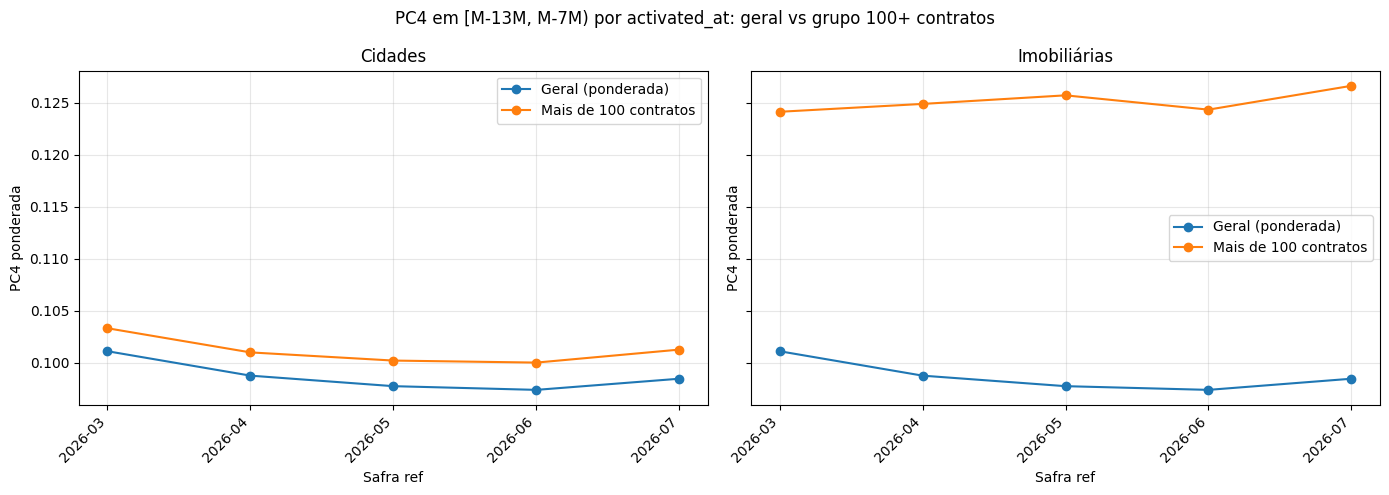

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, title, geral_df, over_df in [
    (axes[0], "Cidades", summary_geral_city, summary_100_city),
    (axes[1], "Imobiliárias", summary_geral_agency, summary_100_agency),
]:
    ax.plot(geral_df["safra_ref"], geral_df["avg_var_ponderada"], marker="o", label="Geral (ponderada)")
    ax.plot(over_df["safra_ref"], over_df["avg_var_ponderada"], marker="o", label="Mais de 100 contratos")
    ax.set_title(title)
    ax.set_xlabel("Safra ref")
    ax.set_ylabel("PC4 ponderada")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle("PC4 em [M-13M, M-7M) por activated_at: geral vs grupo 100+ contratos")
fig.tight_layout()
plt.show()


## Explicação da inadimplência — mar/26 a jul/26

A PC4 da carteira se decompõe em dois grupos (cidade ou imobiliária):

`PC4_geral = w_100+ * PC4_100+ + (1 - w_100+) * PC4_resto`

em que a taxa é `pc_4m` e `w_100+` é a fatia de contratos **com `pc_4m` observado** na janela `[M-13M, M-7M)` que está em entidades com mais de 100 contratos ativados.

Isso compara a inadimplência geral com a do grupo 100+, no mesmo conceito de PC4 do monitoramento.

In [54]:
EXPLAIN_REFS = [ref for ref in ref_safras if "2026-03" <= ref <= "2026-07"]


def window_activated(ref):
    ref_dt = pd.to_datetime(f"{ref}-01")
    start = ref_dt + MonthBegin(-13)
    end = ref_dt + MonthBegin(-7)
    mask = (df_act["activated_dt"] >= start) & (df_act["activated_dt"] < end)
    return start, end, df_act.loc[mask].copy()


def decompose_group(window, entity_col, min_contracts=MIN_CONTRACTS):
    stats = (
        window.groupby(entity_col, dropna=True)
        .agg(
            n_ones=("pc_4m", "sum"),
            n_obs=("pc_4m", "count"),
            n_contracts=("contract_id", "nunique"),
        )
        .reset_index()
    )
    stats["pc4"] = np.where(stats["n_obs"] > 0, stats["n_ones"] / stats["n_obs"], np.nan)
    stats["is_100"] = stats["n_contracts"] > min_contracts
    over = stats[stats["is_100"]]
    resto = stats[~stats["is_100"]]

    n = stats["n_obs"].sum()
    n_100 = over["n_obs"].sum()
    n_resto = resto["n_obs"].sum()
    w_100 = n_100 / n if n else np.nan

    def pooled(df):
        n_obs = df["n_obs"].sum()
        return (df["n_ones"].sum() / n_obs) if n_obs else np.nan

    pc4_geral = pooled(stats)
    pc4_100 = pooled(over)
    pc4_resto = pooled(resto)

    return stats.assign(safra_ref=None), {
        "n_contracts": int(stats["n_contracts"].sum()),
        "n_entities": int(len(stats)),
        "n_entities_100": int(len(over)),
        "n_contracts_100": int(over["n_contracts"].sum()),
        "n_contracts_resto": int(resto["n_contracts"].sum()),
        "n_pc4": int(n),
        "n_pc4_100": int(n_100),
        "n_pc4_resto": int(n_resto),
        "w_100": w_100,
        "pc4_geral": pc4_geral,
        "pc4_100": pc4_100,
        "pc4_resto": pc4_resto,
        "contrib_100": w_100 * pc4_100 if pd.notna(w_100) and pd.notna(pc4_100) else np.nan,
        "contrib_resto": (1 - w_100) * pc4_resto if pd.notna(w_100) and pd.notna(pc4_resto) else np.nan,
        "gap_100_vs_geral": pc4_100 - pc4_geral if pd.notna(pc4_100) and pd.notna(pc4_geral) else np.nan,
        "gap_100_vs_resto": pc4_100 - pc4_resto if pd.notna(pc4_100) and pd.notna(pc4_resto) else np.nan,
    }


def shift_share(prev, curr):
    if prev is None:
        return {"d_pc4_geral": np.nan, "efeito_taxa_100": np.nan, "efeito_taxa_resto": np.nan, "efeito_mix": np.nan}
    return {
        "d_pc4_geral": curr["pc4_geral"] - prev["pc4_geral"],
        "efeito_taxa_100": prev["w_100"] * (curr["pc4_100"] - prev["pc4_100"]),
        "efeito_taxa_resto": (1 - prev["w_100"]) * (curr["pc4_resto"] - prev["pc4_resto"]),
        "efeito_mix": (curr["w_100"] - prev["w_100"]) * (curr["pc4_100"] - curr["pc4_resto"]),
    }


explain_rows = []
entity_change = {}
prev = {"city": None, "agency": None}

for ref in EXPLAIN_REFS:
    start, end, window = window_activated(ref)
    for entity_col, entity_type in [("id_cidade_ibge", "city"), ("id_imobiliaria", "agency")]:
        stats, metrics = decompose_group(window, entity_col)
        effects = shift_share(prev[entity_type], metrics)
        explain_rows.append(
            {
                "safra_ref": ref,
                "window_start": start.strftime("%Y-%m"),
                "window_end_exclusive": end.strftime("%Y-%m"),
                "entity_type": entity_type,
                **metrics,
                **effects,
            }
        )
        stats = stats.assign(safra_ref=ref, entity_type=entity_type)
        entity_change.setdefault(entity_type, []).append(stats)
        prev[entity_type] = metrics

explain = pd.DataFrame(explain_rows)
explain_city = explain[explain["entity_type"] == "city"].reset_index(drop=True)
explain_agency = explain[explain["entity_type"] == "agency"].reset_index(drop=True)

print("Cidades — decomposição mar/26 a jul/26")
explain_city[
    [
        "safra_ref",
        "n_contracts",
        "n_pc4",
        "w_100",
        "pc4_geral",
        "pc4_100",
        "pc4_resto",
        "contrib_100",
        "contrib_resto",
        "gap_100_vs_geral",
        "d_pc4_geral",
        "efeito_taxa_100",
        "efeito_taxa_resto",
        "efeito_mix",
    ]
]

Cidades — decomposição mar/26 a jul/26


,safra_ref,n_contracts,n_pc4,w_100,pc4_geral,pc4_100,pc4_resto,contrib_100,contrib_resto,gap_100_vs_geral,d_pc4_geral,efeito_taxa_100,efeito_taxa_resto,efeito_mix
0,2026-03,106102,106102,0.888400,0.101101,0.103309,0.083523,0.091780,0.009321,0.002208,NaN,NaN,NaN,NaN
1,2026-04,107296,107296,0.891869,0.098755,0.100989,0.080331,0.090069,0.008686,0.002234,-0.002346,-0.002061,-0.000356,0.000072
2,2026-05,108938,108938,0.889157,0.097744,0.100203,0.078012,0.089097,0.008647,0.002460,-0.001011,-0.000700,-0.000251,-0.000060
3,2026-06,110055,110055,0.890473,0.097388,0.100009,0.076074,0.089055,0.008332,0.002622,-0.000356,-0.000173,-0.000215,0.000031
4,2026-07,107801,107801,0.888359,0.098459,0.101257,0.076194,0.089953,0.008506,0.002798,0.001072,0.001111,0.000013,-0.000053


In [55]:
print("Imobiliárias — decomposição mar/26 a jul/26")
explain_agency[
    [
        "safra_ref",
        "n_contracts",
        "n_pc4",
        "w_100",
        "pc4_geral",
        "pc4_100",
        "pc4_resto",
        "contrib_100",
        "contrib_resto",
        "gap_100_vs_geral",
        "d_pc4_geral",
        "efeito_taxa_100",
        "efeito_taxa_resto",
        "efeito_mix",
    ]
]

Imobiliárias — decomposição mar/26 a jul/26


,safra_ref,n_contracts,n_pc4,w_100,pc4_geral,pc4_100,pc4_resto,contrib_100,contrib_resto,gap_100_vs_geral,d_pc4_geral,efeito_taxa_100,efeito_taxa_resto,efeito_mix
0,2026-03,106102,106102,0.266018,0.101101,0.124110,0.092762,0.033015,0.068085,0.023009,NaN,NaN,NaN,NaN
1,2026-04,107296,107296,0.276394,0.098755,0.124865,0.088782,0.034512,0.064243,0.026110,-0.002346,0.000201,-0.002921,0.000374
2,2026-05,108938,108938,0.272852,0.097744,0.125690,0.087257,0.034295,0.063449,0.027946,-0.001011,0.000228,-0.001103,-0.000136
3,2026-06,110055,110055,0.273872,0.097388,0.124316,0.087231,0.034047,0.063341,0.026928,-0.000356,-0.000375,-0.000019,0.000038
4,2026-07,107801,107801,0.267799,0.098459,0.126606,0.088164,0.033905,0.064554,0.028147,0.001072,0.000627,0.000678,-0.000233


### Como ler os gráficos desta seção

**Gráfico de linhas (PC4):** três taxas no mesmo recorte.

- **Geral (carteira):** `mean(pc_4m)` de todos os contratos maduros na janela.
- **Grupo 100+:** média ponderada só das cidades/imobiliárias com mais de 100 contratos.
- **Resto (<100):** média ponderada das demais. Se o 100+ sobe e o resto cai, a carteira só acompanha o 100+ na medida da fatia de volume (`w_100+`).

**Gráfico de barras (variação mês a mês):** quebra o `Δ PC4 geral` em três pedaços que somam o ponto preto.

- **Efeito taxa 100+:** a inadimplência *dentro* do grupo grande mudou, com o peso do mês anterior. Ex.: as mesmas cidades 100+ passaram de 10% para 12% de PC4.
- **Efeito taxa resto:** a mesma ideia para entidades com 100 contratos ou menos.
- **Efeito mix:** a *composição* da carteira mudou. Mais volume nas entidades grandes (ou menos) altera a PC4 geral mesmo se nenhuma taxa individual tiver mudado. O sinal segue o gap 100+ vs resto: se o 100+ é pior e ganha share, o mix sobe a carteira.

Em uma frase: **taxa** = “as entidades ficaram piores/melhores”; **mix** = “mudou quem pesa mais na carteira”.

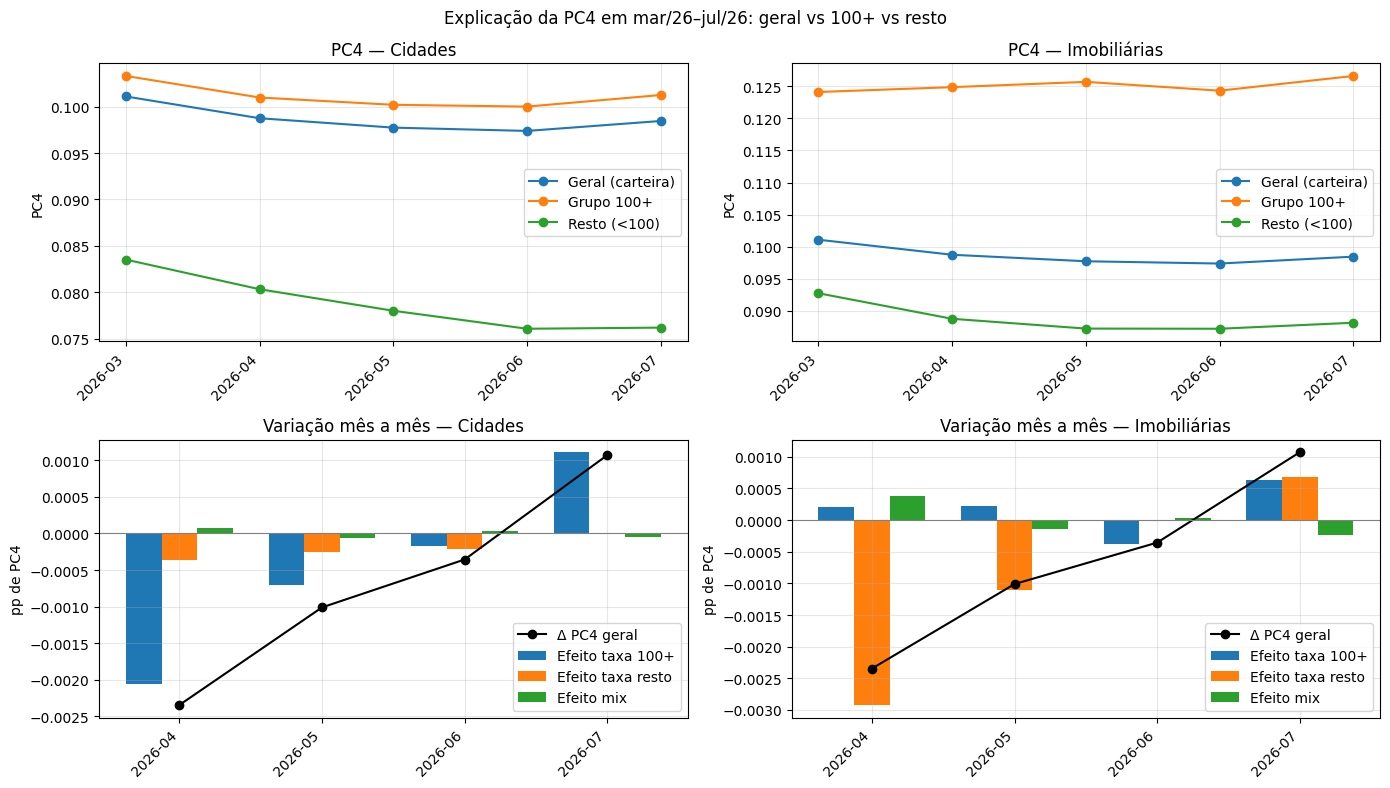

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (entity_type, title, data) in enumerate(
    [("city", "Cidades", explain_city), ("agency", "Imobiliárias", explain_agency)]
):
    ax = axes[0, col]
    ax.plot(data["safra_ref"], data["pc4_geral"], marker="o", label="Geral (carteira)")
    ax.plot(data["safra_ref"], data["pc4_100"], marker="o", label="Grupo 100+")
    ax.plot(data["safra_ref"], data["pc4_resto"], marker="o", label="Resto (<100)")
    ax.set_title(f"PC4 — {title}")
    ax.set_ylabel("PC4")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax2 = axes[1, col]
    effects = data.dropna(subset=["d_pc4_geral"])
    x = np.arange(len(effects))
    width = 0.25
    ax2.bar(x - width, effects["efeito_taxa_100"], width, label="Efeito taxa 100+")
    ax2.bar(x, effects["efeito_taxa_resto"], width, label="Efeito taxa resto")
    ax2.bar(x + width, effects["efeito_mix"], width, label="Efeito mix")
    ax2.plot(x, effects["d_pc4_geral"], marker="o", color="black", label="Δ PC4 geral")
    ax2.set_xticks(x, effects["safra_ref"])
    ax2.set_title(f"Variação mês a mês — {title}")
    ax2.set_ylabel("pp de PC4")
    ax2.axhline(0, color="gray", linewidth=0.8)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

fig.suptitle("Explicação da PC4 em mar/26–jul/26: geral vs 100+ vs resto")
fig.tight_layout()
plt.show()

### Evolução PC4

Mesmo desenho da série histórica:

- **PC4 observado** (preto): taxa por safra de `requested_at` (`summary["pc_4m"]`)
- **Trajetória 2026-08-01** (vermelho): as safras da janela `[2025-07, 2026-01)` — o histórico que a referência de agosto enxerga
- **Cinza:** média ponderada das cidades/imobiliárias com mais de 100 contratos, por **mês de referência** (janela `[M-13M, M-7M)` em `activated_at`)
- **Tracejado:** `2026-08-01`

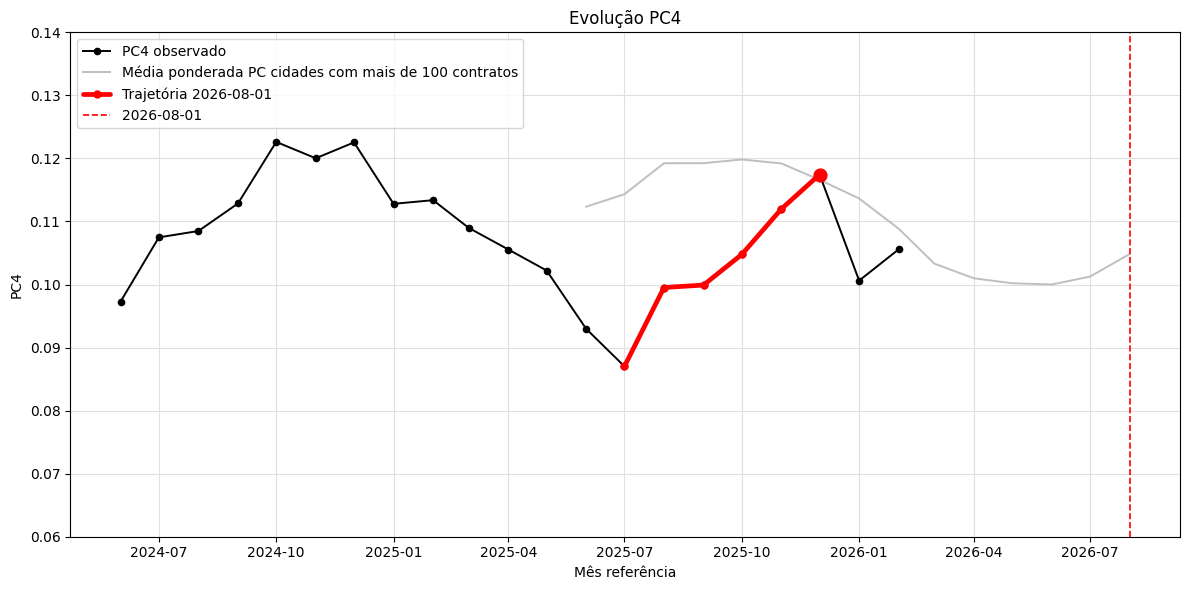

In [57]:
import matplotlib.dates as mdates

REF_TARGET = pd.Timestamp("2026-08-01")
TRAJ_START = REF_TARGET + MonthBegin(-13)  # 2025-07
TRAJ_END = REF_TARGET + MonthBegin(-7)     # 2026-01 exclusive

obs = summary.loc[summary["pc_4m"].notna(), ["safra", "pc_4m", "n_4_pc4"]].copy()
obs["ref_dt"] = pd.to_datetime(obs["safra"] + "-01")
traj = obs[(obs["ref_dt"] >= TRAJ_START) & (obs["ref_dt"] < TRAJ_END)]

grey_refs = pd.period_range("2025-06", "2026-08", freq="M").astype(str)
grey_rows = []
for ref in grey_refs:
    _, _, window = window_activated(ref)
    if window.empty:
        continue
    for entity_col, entity_type in [("id_cidade_ibge", "city"), ("id_imobiliaria", "agency")]:
        _, metrics = decompose_group(window, entity_col)
        if pd.notna(metrics["pc4_100"]):
            grey_rows.append({"safra_ref": ref, "entity_type": entity_type, "pc4_100": metrics["pc4_100"]})

grey = pd.DataFrame(grey_rows)
grey["ref_dt"] = pd.to_datetime(grey["safra_ref"] + "-01")
grey_city = grey[grey["entity_type"] == "city"]
grey_agency = grey[grey["entity_type"] == "agency"]


def plot_evolucao_original(ax, grey_df, grey_label):
    ax.plot(
        obs["ref_dt"],
        obs["pc_4m"],
        color="black",
        marker="o",
        markersize=4.5,
        linewidth=1.4,
        label="PC4 observado",
        zorder=3,
    )
    ax.plot(
        grey_df["ref_dt"],
        grey_df["pc4_100"],
        color="0.75",
        linewidth=1.4,
        label=grey_label,
        zorder=2,
    )
    ax.plot(
        traj["ref_dt"],
        traj["pc_4m"],
        color="red",
        marker="o",
        markersize=5,
        linewidth=3.4,
        solid_capstyle="round",
        label="Trajetória 2026-08-01",
        zorder=4,
    )
    ax.scatter([traj["ref_dt"].iloc[-1]], [traj["pc_4m"].iloc[-1]], color="red", s=85, zorder=5)
    ax.axvline(REF_TARGET, color="red", linestyle="--", linewidth=1.2, label="2026-08-01")
    ax.set_title("Evolução PC4")
    ax.set_xlabel("Mês referência")
    ax.set_ylabel("PC4")
    # ax.set_xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2027-01-01"))
    ax.set_ylim(0.06, 0.14)
    # ax.set_xticks(pd.date_range("2024-01-01", "2027-01-01", freq="4MS"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.grid(True, color="0.88")
    ax.legend(loc="upper left", frameon=True)


fig, ax = plt.subplots(figsize=(12, 6))
plot_evolucao_original(
    ax,
    grey_city,
    "Média ponderada PC cidades com mais de 100 contratos",
)
fig.tight_layout()
plt.show()


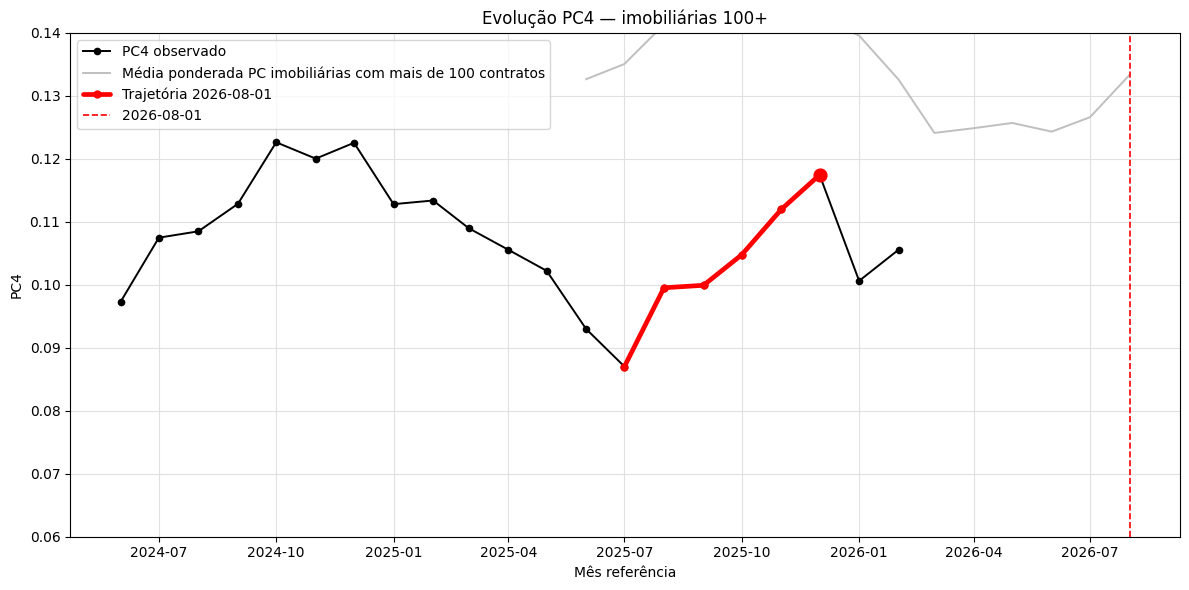

In [58]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_evolucao_original(
    ax,
    grey_agency,
    "Média ponderada PC imobiliárias com mais de 100 contratos",
)
ax.set_title("Evolução PC4 — imobiliárias 100+")
fig.tight_layout()
plt.show()


### Animação — cidades 100+ por mês de ativação

A linha vermelha agora agrupa por `activated_dt`, a mesma data da janela `[M-13M, M-7M)`. Os pontos ficam dentro da janela e o peso se espalha pelos ~6 meses.

In [59]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

obs = summary.loc[summary["pc_4m"].notna(), ["safra", "pc_4m", "n_4_pc4"]].copy()
obs["ref_dt"] = pd.to_datetime(obs["safra"] + "-01")

refs = pd.period_range("2025-09", "2026-10", freq="M").to_timestamp()

frames_100 = []
for ref_dt in refs:
    start = ref_dt + MonthBegin(-13)
    end = ref_dt + MonthBegin(-7)
    window = df_act.loc[
        (df_act["activated_dt"] >= start) & (df_act["activated_dt"] < end)
    ].copy()
    if window.empty:
        frames_100.append(
            {
                "ref_dt": ref_dt,
                "start": start,
                "end": end,
                "vintages": pd.DataFrame(columns=["safra_dt", "pc_4m", "n_4_pc4"]),
                "x_val": None,
                "n_cities": 0,
            }
        )
        continue

    city_n = window.groupby("id_cidade_ibge")["contract_id"].nunique()
    cities_100 = city_n[city_n > MIN_CONTRACTS].index
    w100 = window[window["id_cidade_ibge"].isin(cities_100)].copy()

    vintages = (
        w100.groupby("activated_dt", as_index=False)
        .agg(pc_4m=("pc_4m", "mean"), n_4_pc4=("pc_4m", "count"))
        .rename(columns={"activated_dt": "safra_dt"})
    )
    n = vintages["n_4_pc4"].sum()
    x_val = (vintages["pc_4m"] * vintages["n_4_pc4"]).sum() / n if n else None
    frames_100.append(
        {
            "ref_dt": ref_dt,
            "start": start,
            "end": end,
            "vintages": vintages,
            "x_val": x_val,
            "n_cities": int(len(cities_100)),
        }
    )

fig, (ax, axb) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2.2, 1]})

ax.plot(obs["ref_dt"], obs["pc_4m"], color="black", marker="o", linewidth=1.4, label="PC4 observado (geral)")
traj_line, = ax.plot([], [], color="red", marker="o", linewidth=3.4, label="PCC4 nas cidades 100+")
vline = ax.axvline(refs[0], color="red", linestyle="--", linewidth=1.2)
x_point = ax.scatter([], [], color="red", s=90, zorder=5)
title = ax.set_title("")
ax.set_xlim(pd.Timestamp("2024-06-01"), pd.Timestamp("2026-10-01"))
ax.set_ylim(0.06, 0.14)
ax.set_ylabel("PC4")
ax.grid(True, color="0.88")
ax.legend(loc="upper left")

bars = axb.bar(obs["ref_dt"], [0] * len(obs), width=20, color="red", alpha=0.7)
axb.set_xlim(ax.get_xlim())
axb.set_ylabel("Peso na janela 100+")
axb.set_xlabel("Mês de Referência")
axb.grid(True, color="0.88")


def frame(i):
    f = frames_100[i]
    vintages = f["vintages"]
    traj_line.set_data(vintages["safra_dt"], vintages["pc_4m"])
    vline.set_xdata([f["ref_dt"], f["ref_dt"]])
    if f["x_val"] is not None and len(vintages):
        x_point.set_offsets([[f["ref_dt"], f["x_val"]]])
        title.set_text(
            f"M = {f['ref_dt']:%Y-%m}  |  janela [{f['start']:%Y-%m}, {f['end']:%Y-%m})  |  "
            f"cidades 100+ = {f['n_cities']}  |  X = {f['x_val']:.3f}"
        )
    else:
        x_point.set_offsets(np.empty((0, 2)))
        title.set_text(f"M = {f['ref_dt']:%Y-%m}  |  sem cidades 100+")

    total = vintages["n_4_pc4"].sum() if len(vintages) else 0
    weight_map = (
        dict(zip(vintages["safra_dt"], vintages["n_4_pc4"] / total))
        if total
        else {}
    )
    for bar, dt in zip(bars, obs["ref_dt"]):
        bar.set_height(weight_map.get(dt, 0))
    return traj_line, vline, x_point, title, *bars


anim = FuncAnimation(fig, frame, frames=range(len(frames_100)), interval=700, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

In [60]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

obs = summary.loc[summary["pcc_4m"].notna(), ["safra", "pcc_4m", "n_4_pcc4"]].copy()
obs["ref_dt"] = pd.to_datetime(obs["safra"] + "-01")

refs = pd.period_range("2025-09", "2026-12", freq="M").to_timestamp()

frames_100 = []
for ref_dt in refs:
    start = ref_dt + MonthBegin(-13)
    end = ref_dt + MonthBegin(-7)
    window = df_act.loc[
        (df_act["activated_dt"] >= start) & (df_act["activated_dt"] < end)
    ].copy()
    if window.empty:
        frames_100.append(
            {
                "ref_dt": ref_dt,
                "start": start,
                "end": end,
                "vintages": pd.DataFrame(columns=["safra_dt", "pcc_4m", "n_4_pcc4"]),
                "x_val": None,
                "n_cities": 0,
            }
        )
        continue

    city_n = window.groupby("id_cidade_ibge")["contract_id"].nunique()
    cities_100 = city_n[city_n > MIN_CONTRACTS].index
    w100 = window[window["id_cidade_ibge"].isin(cities_100)].copy()

    vintages = (
        w100.groupby("activated_dt", as_index=False)
        .agg(pcc_4m=("pcc_4m", "mean"), n_4_pcc4=("contract_id", "nunique"))
        .rename(columns={"activated_dt": "safra_dt"})
    )
    n = vintages["n_4_pcc4"].sum()
    x_val = (vintages["pcc_4m"] * vintages["n_4_pcc4"]).sum() / n if n else None
    frames_100.append(
        {
            "ref_dt": ref_dt,
            "start": start,
            "end": end,
            "vintages": vintages,
            "x_val": x_val,
            "n_cities": int(len(cities_100)),
        }
    )

fig, (ax, axb) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2.2, 1]})

ax.plot(obs["ref_dt"], obs["pcc_4m"], color="black", marker="o", linewidth=1.4, label="PCC4 observado (geral)")
traj_line, = ax.plot([], [], color="red", marker="o", linewidth=3.4, label="PCC4 nas cidades 100+")
vline = ax.axvline(refs[0], color="red", linestyle="--", linewidth=1.2)
x_point = ax.scatter([], [], color="red", s=90, zorder=5)
title = ax.set_title("")
ax.set_xlim(pd.Timestamp("2024-06-01"), pd.Timestamp("2026-12-01"))
ax.set_ylim(0.06, 0.14)
ax.set_ylabel("PCC4")
ax.grid(True, color="0.88")
ax.legend(loc="upper left")

bars = axb.bar(obs["ref_dt"], [0] * len(obs), width=20, color="red", alpha=0.7)
axb.set_xlim(ax.get_xlim())
axb.set_ylabel("Peso na janela 100+")
axb.set_xlabel("Mês de Referência")
axb.grid(True, color="0.88")


def frame(i):
    f = frames_100[i]
    vintages = f["vintages"]
    traj_line.set_data(vintages["safra_dt"], vintages["pcc_4m"])
    vline.set_xdata([f["ref_dt"], f["ref_dt"]])
    if f["x_val"] is not None and len(vintages):
        x_point.set_offsets([[f["ref_dt"], f["x_val"]]])
        title.set_text(
            f"M = {f['ref_dt']:%Y-%m}  |  janela [{f['start']:%Y-%m}, {f['end']:%Y-%m})  |  "
            f"cidades 100+ = {f['n_cities']}  |  X = {f['x_val']:.3f}"
        )
    else:
        x_point.set_offsets(np.empty((0, 2)))
        title.set_text(f"M = {f['ref_dt']:%Y-%m}  |  sem cidades 100+")

    total = vintages["n_4_pcc4"].sum() if len(vintages) else 0
    weight_map = (
        dict(zip(vintages["safra_dt"], vintages["n_4_pcc4"] / total))
        if total
        else {}
    )
    for bar, dt in zip(bars, obs["ref_dt"]):
        bar.set_height(weight_map.get(dt, 0))
    return traj_line, vline, x_point, title, *bars


anim = FuncAnimation(fig, frame, frames=range(len(frames_100)), interval=700, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

In [61]:
df_sim_ctr[["id_cidade_ibge", "id_imobiliaria"]]

,id_cidade_ibge,id_imobiliaria
0,3501608,33400
1,4119905,30599
2,3526902,4549
3,3538709,15846
4,3501608,2863
...,...,...
2701156,4314902,11153
2701157,4107652,10417
2701158,4311403,3933
2701159,4105508,19049


In [62]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

obs = summary.loc[summary["pcc_4m"].notna(), ["safra", "pcc_4m", "n_4_pcc4"]].copy()
obs["ref_dt"] = pd.to_datetime(obs["safra"] + "-01")

refs = pd.period_range("2025-09", "2026-12", freq="M").to_timestamp()

frames_100 = []
for ref_dt in refs:
    start = ref_dt + MonthBegin(-13)
    end = ref_dt + MonthBegin(-7)
    window = df_act.loc[
        (df_act["activated_dt"] >= start) & (df_act["activated_dt"] < end)
    ].copy()
    if window.empty:
        frames_100.append(
            {
                "ref_dt": ref_dt,
                "start": start,
                "end": end,
                "vintages": pd.DataFrame(columns=["safra_dt", "pcc_4m", "n_4_pcc4"]),
                "x_val": None,
                "n_cities": 0,
            }
        )
        continue

    agency_n = window.groupby("id_imobiliaria")["contract_id"].nunique()
    agencies_100 = agency_n[agency_n > MIN_CONTRACTS].index
    w100 = window[window["id_imobiliaria"].isin(agencies_100)].copy()

    vintages = (
        w100.groupby("activated_dt", as_index=False)
        .agg(pcc_4m=("pcc_4m", "mean"), n_4_pcc4=("contract_id", "nunique"))
        .rename(columns={"activated_dt": "safra_dt"})
    )
    n = vintages["n_4_pcc4"].sum()
    x_val = (vintages["pcc_4m"] * vintages["n_4_pcc4"]).sum() / n if n else None
    frames_100.append(
        {
            "ref_dt": ref_dt,
            "start": start,
            "end": end,
            "vintages": vintages,
            "x_val": x_val,
            "n_agencies": int(len(agencies_100)),
        }
    )

fig, (ax, axb) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2.2, 1]})

ax.plot(obs["ref_dt"], obs["pcc_4m"], color="black", marker="o", linewidth=1.4, label="PCC4 observado (geral)")
traj_line, = ax.plot([], [], color="red", marker="o", linewidth=3.4, label="PCC4 nas Imobiliárias 100+")
vline = ax.axvline(refs[0], color="red", linestyle="--", linewidth=1.2)
x_point = ax.scatter([], [], color="red", s=90, zorder=5)
title = ax.set_title("")
ax.set_xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2026-12-01"))
ax.set_ylim(0.06, 0.14)
ax.set_ylabel("PCC4")
ax.grid(True, color="0.88")
ax.legend(loc="upper left")

bars = axb.bar(obs["ref_dt"], [0] * len(obs), width=20, color="red", alpha=0.7)
axb.set_xlim(ax.get_xlim())
axb.set_ylabel("Peso na janela 100+")
axb.set_xlabel("Mês de Referência")
axb.grid(True, color="0.88")


def frame(i):
    f = frames_100[i]
    vintages = f["vintages"]
    traj_line.set_data(vintages["safra_dt"], vintages["pcc_4m"])
    vline.set_xdata([f["ref_dt"], f["ref_dt"]])
    if f["x_val"] is not None and len(vintages):
        x_point.set_offsets([[f["ref_dt"], f["x_val"]]])
        title.set_text(
            f"M = {f['ref_dt']:%Y-%m}  |  janela [{f['start']:%Y-%m}, {f['end']:%Y-%m})  |  "
            f"Imobiliárias 100+ = {f['n_agencies']}  |  X = {f['x_val']:.3f}"
        )
    else:
        x_point.set_offsets(np.empty((0, 2)))
        title.set_text(f"M = {f['ref_dt']:%Y-%m}  |  sem Imobiliárias 100+")

    total = vintages["n_4_pcc4"].sum() if len(vintages) else 0
    weight_map = (
        dict(zip(vintages["safra_dt"], vintages["n_4_pcc4"] / total))
        if total
        else {}
    )
    for bar, dt in zip(bars, obs["ref_dt"]):
        bar.set_height(weight_map.get(dt, 0))
    return traj_line, vline, x_point, title, *bars


anim = FuncAnimation(fig, frame, frames=range(len(frames_100)), interval=700, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

In [63]:
from IPython.display import display


def top_entity_drivers(entity_type, entity_col, first_ref="2026-03", last_ref="2026-07", n=10):
    first = pd.concat(
        [df for df in entity_change[entity_type] if df["safra_ref"].iloc[0] == first_ref],
        ignore_index=True,
    )
    last = pd.concat(
        [df for df in entity_change[entity_type] if df["safra_ref"].iloc[0] == last_ref],
        ignore_index=True,
    )
    n_first = first["n_obs"].sum()
    n_last = last["n_obs"].sum()
    first = first.rename(columns={"pc4": "pc4_first", "n_ones": "n_ones_first", "n_obs": "n_first"})
    last = last.rename(columns={"pc4": "pc4_last", "n_ones": "n_ones_last", "n_obs": "n_last"})
    merged = first[[entity_col, "pc4_first", "n_ones_first", "n_first", "is_100"]].merge(
        last[[entity_col, "pc4_last", "n_ones_last", "n_last"]],
        on=entity_col,
        how="outer",
    )
    merged["n_first"] = merged["n_first"].fillna(0)
    merged["n_last"] = merged["n_last"].fillna(0)
    merged["n_ones_first"] = merged["n_ones_first"].fillna(0)
    merged["n_ones_last"] = merged["n_ones_last"].fillna(0)
    merged["pc4_first"] = np.where(merged["n_first"] > 0, merged["n_ones_first"] / merged["n_first"], 0)
    merged["pc4_last"] = np.where(merged["n_last"] > 0, merged["n_ones_last"] / merged["n_last"], 0)
    merged["contrib_first"] = merged["n_ones_first"] / n_first
    merged["contrib_last"] = merged["n_ones_last"] / n_last
    merged["d_contrib"] = merged["contrib_last"] - merged["contrib_first"]
    merged["group"] = np.where(merged["is_100"].fillna(False), "100+", "resto")
    return merged.sort_values("d_contrib", ascending=False)


drivers_city = top_entity_drivers("city", "id_cidade_ibge")
drivers_agency = top_entity_drivers("agency", "id_imobiliaria")

print("Cidades que mais puxaram a PC4 de mar/26 a jul/26 (alta)")
display(drivers_city.head(10))
print("Cidades que mais aliviaram a PC4 de mar/26 a jul/26 (queda)")
display(drivers_city.tail(10).sort_values("d_contrib"))

Cidades que mais puxaram a PC4 de mar/26 a jul/26 (alta)


,id_cidade_ibge,pc4_first,n_ones_first,n_first,is_100,pc4_last,n_ones_last,n_last,contrib_first,contrib_last,d_contrib,group
117,3122306,0.144725,155,1071,True,0.183908,240,1305,0.001461,0.002226,0.000765,100+
618,4115200,0.070835,162,2287,True,0.082222,222,2700,0.001527,0.002059,0.000533,100+
494,3543907,0.124214,79,636,True,0.155995,134,859,0.000745,0.001243,0.000498,100+
201,3170206,0.143739,163,1134,True,0.149858,211,1408,0.001536,0.001957,0.000421,100+
370,3518800,0.130159,82,630,True,0.138372,119,860,0.000773,0.001104,0.000331,100+
866,4316907,0.130511,74,567,True,0.118138,99,838,0.000697,0.000918,0.000221,100+
847,4313409,0.114420,73,638,True,0.145482,95,653,0.000688,0.000881,0.000193,100+
733,4211306,0.061360,37,603,True,0.071078,58,816,0.000349,0.000538,0.000189,100+
803,4305108,0.097612,188,1926,True,0.101883,211,2071,0.001772,0.001957,0.000185,100+
492,3543402,0.116253,103,886,True,0.124498,124,996,0.000971,0.00115,0.00018,100+


Cidades que mais aliviaram a PC4 de mar/26 a jul/26 (queda)


,id_cidade_ibge,pc4_first,n_ones_first,n_first,is_100,pc4_last,n_ones_last,n_last,contrib_first,contrib_last,d_contrib,group
857,4314902,0.107498,324,3014,True,0.088592,212,2393,0.003054,0.001967,-0.001087,100+
404,3524402,0.121182,123,1015,True,0.082329,82,996,0.001159,0.000761,-0.000399,100+
421,3526902,0.134655,197,1463,True,0.120729,159,1317,0.001857,0.001475,-0.000382,100+
591,4106902,0.084746,200,2360,True,0.076598,163,2128,0.001885,0.001512,-0.000373,100+
255,3304557,0.076043,133,1749,True,0.057856,95,1642,0.001254,0.000881,-0.000372,100+
303,3506508,0.140659,64,455,True,0.099698,33,331,0.000603,0.000306,-0.000297,100+
950,5208707,0.162420,306,1884,True,0.174891,280,1601,0.002884,0.002597,-0.000287,100+
536,3552205,0.087288,103,1180,True,0.082774,74,894,0.000971,0.000686,-0.000284,100+
31,2304400,0.144120,163,1131,True,0.122616,135,1101,0.001536,0.001252,-0.000284,100+
969,5300108,0.069137,153,2213,True,0.060445,125,2068,0.001442,0.00116,-0.000282,100+


In [64]:
print("Imobiliárias que mais puxaram a PC4 de mar/26 a jul/26 (alta)")
display(drivers_agency.head(10))
print("Imobiliárias que mais aliviaram a PC4 de mar/26 a jul/26 (queda)")
display(drivers_agency.tail(10).sort_values("d_contrib"))

city_from = explain_city.iloc[0]
city_to = explain_city.iloc[-1]
agency_from = explain_agency.iloc[0]
agency_to = explain_agency.iloc[-1]

print("\n--- Leitura do período ---")
print(
    f"Cidades: PC4 geral {city_from['safra_ref']} {city_from['pc4_geral']:.4f} -> "
    f"{city_to['safra_ref']} {city_to['pc4_geral']:.4f} (Δ {city_to['pc4_geral'] - city_from['pc4_geral']:+.4f})"
)
print(
    f"  100+  {city_from['pc4_100']:.4f} -> {city_to['pc4_100']:.4f} | "
    f"resto {city_from['pc4_resto']:.4f} -> {city_to['pc4_resto']:.4f} | "
    f"w_100+ {city_from['w_100']:.1%} -> {city_to['w_100']:.1%}"
)
print(
    f"Imobiliárias: PC4 geral {agency_from['safra_ref']} {agency_from['pc4_geral']:.4f} -> "
    f"{agency_to['safra_ref']} {agency_to['pc4_geral']:.4f} (Δ {agency_to['pc4_geral'] - agency_from['pc4_geral']:+.4f})"
)
print(
    f"  100+  {agency_from['pc4_100']:.4f} -> {agency_to['pc4_100']:.4f} | "
    f"resto {agency_from['pc4_resto']:.4f} -> {agency_to['pc4_resto']:.4f} | "
    f"w_100+ {agency_from['w_100']:.1%} -> {agency_to['w_100']:.1%}"
)

Imobiliárias que mais puxaram a PC4 de mar/26 a jul/26 (alta)


,id_imobiliaria,pc4_first,n_ones_first,n_first,is_100,pc4_last,n_ones_last,n_last,contrib_first,contrib_last,d_contrib,group
246,923,0.107317,66,615,True,0.129388,129,997,0.000622,0.001197,0.000575,100+
1370,6422,0.155844,108,693,True,0.193248,166,859,0.001018,0.00154,0.000522,100+
353,1225,0.174905,46,263,True,0.195312,100,512,0.000434,0.000928,0.000494,100+
2344,12208,0.027397,6,219,True,0.061404,28,456,0.000057,0.00026,0.000203,100+
622,2164,0.205479,60,292,True,0.235465,81,344,0.000565,0.000751,0.000186,100+
1280,5821,0.140625,27,192,True,0.183267,46,251,0.000254,0.000427,0.000172,100+
1073,4490,0.091270,23,252,True,0.103797,41,395,0.000217,0.00038,0.000164,100+
2951,15439,0.193103,56,290,True,0.190231,74,389,0.000528,0.000686,0.000159,100+
136,574,0.000000,0,0,NaN,0.515152,17,33,0.0,0.000158,0.000158,resto
52,314,0.116667,7,60,False,0.225490,23,102,0.000066,0.000213,0.000147,resto


Imobiliárias que mais aliviaram a PC4 de mar/26 a jul/26 (queda)


,id_imobiliaria,pc4_first,n_ones_first,n_first,is_100,pc4_last,n_ones_last,n_last,contrib_first,contrib_last,d_contrib,group
7532,44081,0.408163,40,98,False,0.000000,0,2,0.000377,0.0,-0.000377,resto
891,3419,0.348754,98,281,True,0.298387,74,248,0.000924,0.000686,-0.000237,100+
6918,40470,0.350515,34,97,False,0.257143,9,35,0.00032,0.000083,-0.000237,resto
2098,11153,0.108883,38,349,True,0.089947,17,189,0.000358,0.000158,-0.0002,100+
2279,11985,0.130612,32,245,True,0.122449,12,98,0.000302,0.000111,-0.00019,100+
6944,40682,0.213622,69,323,True,0.196078,50,255,0.00065,0.000464,-0.000187,100+
5340,29865,0.515152,17,33,False,0.000000,0,0,0.00016,0.0,-0.00016,resto
6328,36070,0.301370,22,73,False,0.142857,6,42,0.000207,0.000056,-0.000152,resto
2031,10750,0.351852,19,54,False,0.130435,3,23,0.000179,0.000028,-0.000151,resto
2610,13554,0.248980,61,245,True,0.242105,46,190,0.000575,0.000427,-0.000148,100+



--- Leitura do período ---
Cidades: PC4 geral 2026-03 0.1011 -> 2026-07 0.0985 (Δ -0.0026)
  100+  0.1033 -> 0.1013 | resto 0.0835 -> 0.0762 | w_100+ 88.8% -> 88.8%
Imobiliárias: PC4 geral 2026-03 0.1011 -> 2026-07 0.0985 (Δ -0.0026)
  100+  0.1241 -> 0.1266 | resto 0.0928 -> 0.0882 | w_100+ 26.6% -> 26.8%


## Cidade vs imobiliária — a cidade é ruim ou uma imobiliária puxa?

Mesmo recorte (mar/26 → jul/26, janela `[M-13M, M-7M)`), agora com **`pcc_4m`**.

A taxa é sempre **nº de 1's / nº de contratos observados** (`sum(pcc_4m) / count(pcc_4m)`). Ao subir de imobiliária para cidade (ou para o Brasil), somamos os 1's e os totais — **nunca média de médias**.

Esta seção olha **todas** as cidades da janela, não só as 100+. A coluna `is_100` diz se a cidade entra no grupo da query (`n_contracts > 100` de **ativados** em `[M-13M, M-7M)`). `n_obs` é só quem tem `pcc_4m` preenchido — o corte 100+ usa `n_contracts`, não `n_obs`.

- `is_100`: cidade com mais de 100 contratos ativados na janela de jul/26
- `pcc_ex_top`: PCC4 da cidade **sem** a maior imobiliária (mesma conta: 1's / n)
- `gap_top`: quanto a maior imobiliária infla a cidade
- `hhi` / `share_top`: concentração de volume
- classificação: **concentrada**, **mista** ou **difusa**
- `agency_segmentacao` nas imobiliárias com maiores altas e quedas


In [65]:
from IPython.display import display

FIRST_REF = "2026-03"
LAST_REF = "2026-07"
N_SHOW = 10
MIN_AGENCY_IN_CITY = 10
FLAG = "pcc_4m"


def first_mode(series):
    values = series.dropna()
    if values.empty:
        return np.nan
    modes = values.mode()
    return modes.iloc[0] if len(modes) else values.iloc[0]


def ones_rate(n_ones, n_obs):
    n_ones = n_ones.astype(float)
    n_obs = n_obs.astype(float)
    return np.where(n_obs > 0, n_ones / n_obs, np.nan)


def rollup_rate(df, ones_col="n_ones", obs_col="n_obs"):
    n_ones = df[ones_col].sum()
    n_obs = df[obs_col].sum()
    return (n_ones / n_obs) if n_obs else np.nan


city_dim = (
    df_act.groupby("id_cidade_ibge", dropna=True)
    .agg(imovel_cidade=("imovel_cidade", first_mode), imovel_uf=("imovel_uf", first_mode))
    .reset_index()
)
city_dim["city_label"] = (
    city_dim["imovel_cidade"].fillna("sem cidade") + "/" + city_dim["imovel_uf"].fillna("?")
)

agency_dim = (
    df_act.groupby("id_imobiliaria", dropna=True)
    .agg(agency_segmentacao=("agency_segmentacao", first_mode))
    .reset_index()
)


def city_agency_window(ref):
    _, _, window = window_activated(ref)
    stats = (
        window.groupby(["id_cidade_ibge", "id_imobiliaria"], dropna=True)
        .agg(
            n_ones=(FLAG, "sum"),
            n_obs=(FLAG, "count"),
            n_contracts=("contract_id", "nunique"),
        )
        .reset_index()
    )
    stats["pcc"] = ones_rate(stats["n_ones"], stats["n_obs"])
    stats["safra_ref"] = ref
    return stats


def city_profile(ca):
    totals = (
        ca.groupby("id_cidade_ibge", as_index=False)
        .agg(
            n_ones=("n_ones", "sum"),
            n_obs=("n_obs", "sum"),
            n_contracts=("n_contracts", "sum"),
            n_agencies=("id_imobiliaria", "nunique"),
        )
    )
    totals["pcc_city"] = ones_rate(totals["n_ones"], totals["n_obs"])
    totals["is_100"] = totals["n_contracts"] > MIN_CONTRACTS

    profile = ca.merge(
        totals[["id_cidade_ibge", "n_ones", "n_obs", "n_agencies", "pcc_city"]],
        on="id_cidade_ibge",
        how="left",
        suffixes=("", "_city"),
    )
    profile["share"] = profile["n_obs"] / profile["n_obs_city"]
    hhi = profile.groupby("id_cidade_ibge")["share"].apply(lambda s: (s**2).sum()).rename("hhi")
    totals = totals.merge(hhi.reset_index(), on="id_cidade_ibge", how="left")

    top_idx = profile.groupby("id_cidade_ibge")["n_obs"].idxmax()
    top = profile.loc[
        top_idx, ["id_cidade_ibge", "id_imobiliaria", "pcc", "n_ones", "n_obs", "share"]
    ].rename(
        columns={
            "id_imobiliaria": "top_agency_id",
            "pcc": "pcc_top",
            "n_ones": "n_ones_top",
            "n_obs": "n_obs_top",
            "share": "share_top",
        }
    )
    totals = totals.merge(top, on="id_cidade_ibge", how="left")
    n_rest = totals["n_obs"] - totals["n_obs_top"]
    totals["pcc_ex_top"] = np.where(
        n_rest > 0,
        (totals["n_ones"] - totals["n_ones_top"]) / n_rest,
        np.nan,
    )
    totals["gap_top"] = totals["pcc_city"] - totals["pcc_ex_top"]

    material = profile[profile["n_obs"] >= MIN_AGENCY_IN_CITY].copy()
    if len(material):
        worst_idx = material.groupby("id_cidade_ibge")["pcc"].idxmax()
        worst = material.loc[
            worst_idx, ["id_cidade_ibge", "id_imobiliaria", "pcc", "n_ones", "n_obs", "share"]
        ].rename(
            columns={
                "id_imobiliaria": "worst_agency_id",
                "pcc": "pcc_worst",
                "n_ones": "n_ones_worst",
                "n_obs": "n_obs_worst",
                "share": "share_worst",
            }
        )
        totals = totals.merge(worst, on="id_cidade_ibge", how="left")
        n_ex_worst = totals["n_obs"] - totals["n_obs_worst"].fillna(0)
        totals["pcc_ex_worst"] = np.where(
            totals["n_obs_worst"].notna() & (n_ex_worst > 0),
            (totals["n_ones"] - totals["n_ones_worst"]) / n_ex_worst,
            np.nan,
        )
        totals["gap_worst"] = totals["pcc_city"] - totals["pcc_ex_worst"]
    else:
        totals["worst_agency_id"] = np.nan
        totals["pcc_worst"] = np.nan
        totals["n_ones_worst"] = np.nan
        totals["n_obs_worst"] = np.nan
        totals["share_worst"] = np.nan
        totals["pcc_ex_worst"] = np.nan
        totals["gap_worst"] = np.nan

    def classify(row):
        share = row["share_top"]
        gap = row["gap_top"] if pd.notna(row["gap_top"]) else 0
        if pd.isna(share):
            return "indefinida"
        if row["n_agencies"] <= 1 or (pd.isna(row["pcc_ex_top"]) and share >= 0.8):
            return "concentrada"
        if share >= 0.35 and gap >= 0.015:
            return "concentrada"
        if gap < 0.008:
            return "difusa"
        return "mista"

    totals["city_pattern"] = totals.apply(classify, axis=1)
    return totals.merge(city_dim, on="id_cidade_ibge", how="left")


ca_first = city_agency_window(FIRST_REF)
ca_last = city_agency_window(LAST_REF)
city_last = city_profile(ca_last)

pair = ca_first.merge(
    ca_last,
    on=["id_cidade_ibge", "id_imobiliaria"],
    how="outer",
    suffixes=("_first", "_last"),
)
for col in ["n_ones_first", "n_ones_last", "n_obs_first", "n_obs_last"]:
    pair[col] = pair[col].fillna(0)
pair["pcc_first"] = ones_rate(pair["n_ones_first"], pair["n_obs_first"])
pair["pcc_last"] = ones_rate(pair["n_ones_last"], pair["n_obs_last"])

n_nat_first = pair["n_obs_first"].sum()
n_nat_last = pair["n_obs_last"].sum()
pair["d_contrib_nat"] = pair["n_ones_last"] / n_nat_last - pair["n_ones_first"] / n_nat_first


def entity_drivers(ca_a, ca_b, entity_col, n_nat_a, n_nat_b):
    first = (
        ca_a.groupby(entity_col, as_index=False)
        .agg(n_ones=("n_ones", "sum"), n_obs=("n_obs", "sum"), n_contracts=("n_contracts", "sum"))
    )
    last = (
        ca_b.groupby(entity_col, as_index=False)
        .agg(n_ones=("n_ones", "sum"), n_obs=("n_obs", "sum"), n_contracts=("n_contracts", "sum"))
    )
    first["pcc"] = ones_rate(first["n_ones"], first["n_obs"])
    last["pcc"] = ones_rate(last["n_ones"], last["n_obs"])
    merged = first.merge(last, on=entity_col, how="outer", suffixes=("_first", "_last"))
    for col in [
        "n_ones_first",
        "n_ones_last",
        "n_obs_first",
        "n_obs_last",
        "n_contracts_first",
        "n_contracts_last",
    ]:
        merged[col] = merged[col].fillna(0)
    merged["pcc_first"] = ones_rate(merged["n_ones_first"], merged["n_obs_first"])
    merged["pcc_last"] = ones_rate(merged["n_ones_last"], merged["n_obs_last"])
    merged["is_100_first"] = merged["n_contracts_first"] > MIN_CONTRACTS
    merged["is_100_last"] = merged["n_contracts_last"] > MIN_CONTRACTS
    merged["d_contrib"] = merged["n_ones_last"] / n_nat_b - merged["n_ones_first"] / n_nat_a
    return merged.sort_values("d_contrib", ascending=False)


drivers_city_pcc = entity_drivers(ca_first, ca_last, "id_cidade_ibge", n_nat_first, n_nat_last)
drivers_agency_pcc = entity_drivers(ca_first, ca_last, "id_imobiliaria", n_nat_first, n_nat_last)

city_last = city_last.merge(
    drivers_city_pcc[["id_cidade_ibge", "d_contrib", "pcc_first", "pcc_last", "n_obs_first", "n_obs_last"]].rename(
        columns={"d_contrib": "d_contrib_city"}
    ),
    on="id_cidade_ibge",
    how="left",
)

valid_pairs = pair[
    (pair["n_obs_last"] >= MIN_AGENCY_IN_CITY)
    & pair["id_cidade_ibge"].isin(city_last["id_cidade_ibge"])
]
corr_city_agency = valid_pairs.merge(
    city_last[["id_cidade_ibge", "pcc_city", "pcc_ex_top", "share_top", "hhi"]],
    on="id_cidade_ibge",
    how="left",
)

print("Correlação (células cidade × imobiliária com n_obs >= 10, janela jul/26)")
print(
    f"  PCC4 imobiliária vs PCC4 cidade:           {corr_city_agency['pcc_last'].corr(corr_city_agency['pcc_city']):.3f}"
)
print(
    f"  PCC4 imobiliária vs PCC4 cidade sem a top: {corr_city_agency['pcc_last'].corr(corr_city_agency['pcc_ex_top']):.3f}"
)
print(
    f"  PCC4 cidade vs share da maior imob.:       {city_last['pcc_city'].corr(city_last['share_top']):.3f}"
)
print(
    f"  PCC4 cidade vs HHI de volume:              {city_last['pcc_city'].corr(city_last['hhi']):.3f}"
)
print("\nPadrão das cidades na janela jul/26 (PCC4 = soma de 1's / n)")
pattern_ones = city_last.groupby("city_pattern", dropna=False).agg(
    n_cities=("id_cidade_ibge", "nunique"),
    n_ones=("n_ones", "sum"),
    n_obs=("n_obs", "sum"),
)
pattern_ones["pcc"] = ones_rate(pattern_ones["n_ones"], pattern_ones["n_obs"])
display(pattern_ones)

print(
    "\nGrupo 100+: mesma regra da query — n_contracts (ativados) > "
    f"{MIN_CONTRACTS} na janela de {LAST_REF}"
)
display(
    city_last.groupby("is_100", dropna=False).agg(
        n_cities=("id_cidade_ibge", "nunique"),
        n_contracts=("n_contracts", "sum"),
        n_ones=("n_ones", "sum"),
        n_obs=("n_obs", "sum"),
    ).assign(pcc=lambda d: ones_rate(d["n_ones"], d["n_obs"]))
)


Correlação (células cidade × imobiliária com n_obs >= 10, janela jul/26)
  PCC4 imobiliária vs PCC4 cidade:           0.391
  PCC4 imobiliária vs PCC4 cidade sem a top: 0.271
  PCC4 cidade vs share da maior imob.:       -0.090
  PCC4 cidade vs HHI de volume:              -0.101

Padrão das cidades na janela jul/26 (PCC4 = soma de 1's / n)


,n_cities,n_ones,n_obs,pcc
city_pattern,,,,
concentrada,428,1210,13836,0.087453
difusa,399,5940,77429,0.076715
mista,49,1605,16536,0.097061



Grupo 100+: mesma regra da query — n_contracts (ativados) > 100 na janela de 2026-07


,n_cities,n_contracts,n_ones,n_obs,pcc
is_100,,,,,
False,682,12035,742,12035,0.061654
True,194,95766,8013,95766,0.083673


In [66]:
def agencies_in_cities(city_ids, n_agencies=5):
    block = (
        pair[pair["id_cidade_ibge"].isin(city_ids)]
        .merge(city_dim, on="id_cidade_ibge", how="left")
        .merge(agency_dim, on="id_imobiliaria", how="left")
        .merge(
            city_last[
                [
                    "id_cidade_ibge",
                    "is_100",
                    "n_contracts",
                    "city_pattern",
                    "share_top",
                    "pcc_city",
                    "pcc_ex_top",
                    "gap_top",
                    "d_contrib_city",
                ]
            ],
            on="id_cidade_ibge",
            how="left",
        )
    )
    block["rank"] = block.groupby("id_cidade_ibge")["d_contrib_nat"].rank(
        ascending=False, method="first"
    )
    top = block[block["rank"] <= n_agencies].copy()
    cols = [
        "city_label",
        "id_cidade_ibge",
        "is_100",
        "n_contracts",
        "city_pattern",
        "d_contrib_city",
        "pcc_city",
        "pcc_ex_top",
        "gap_top",
        "share_top",
        "id_imobiliaria",
        "agency_segmentacao",
        "pcc_first",
        "pcc_last",
        "n_ones_first",
        "n_ones_last",
        "n_obs_first",
        "n_obs_last",
        "d_contrib_nat",
    ]
    return top.sort_values(["d_contrib_city", "d_contrib_nat"], ascending=[False, False])[cols]


top_city_ids = drivers_city_pcc.head(N_SHOW)["id_cidade_ibge"]
bottom_city_ids = drivers_city_pcc.tail(N_SHOW)["id_cidade_ibge"]

top_city_flags = (
    drivers_city_pcc.head(N_SHOW)
    .merge(city_dim, on="id_cidade_ibge", how="left")
    .merge(city_last[["id_cidade_ibge", "is_100", "n_contracts"]], on="id_cidade_ibge", how="left")
)
bottom_city_flags = (
    drivers_city_pcc.tail(N_SHOW)
    .merge(city_dim, on="id_cidade_ibge", how="left")
    .merge(city_last[["id_cidade_ibge", "is_100", "n_contracts"]], on="id_cidade_ibge", how="left")
)

print(
    f"Top {N_SHOW} cidades que puxaram a PCC4: "
    f"{int(top_city_flags['is_100'].sum())} são 100+ na janela {LAST_REF} "
    f"(ativados > {MIN_CONTRACTS})"
)
display(
    top_city_flags[
        [
            "city_label",
            "id_cidade_ibge",
            "is_100",
            "n_contracts",
            "is_100_first",
            "is_100_last",
            "n_contracts_first",
            "n_contracts_last",
            "d_contrib",
        ]
    ]
)
print(
    f"Top {N_SHOW} cidades que aliviaram a PCC4: "
    f"{int(bottom_city_flags['is_100'].sum())} são 100+ na janela {LAST_REF}"
)
display(
    bottom_city_flags.sort_values("d_contrib")[
        [
            "city_label",
            "id_cidade_ibge",
            "is_100",
            "n_contracts",
            "is_100_first",
            "is_100_last",
            "n_contracts_first",
            "n_contracts_last",
            "d_contrib",
        ]
    ]
)

print("Cidades que mais puxaram a PCC4 — imobiliárias que mais contribuíram dentro delas")
display(agencies_in_cities(top_city_ids))
print("Cidades que mais aliviaram a PCC4 — imobiliárias que mais contribuíram dentro delas")
display(agencies_in_cities(bottom_city_ids).sort_values(["d_contrib_city", "d_contrib_nat"]))

top_agency_ids = set(drivers_agency_pcc.head(N_SHOW)["id_imobiliaria"])
overlap_up = pair[
    pair["id_cidade_ibge"].isin(top_city_ids) & pair["id_imobiliaria"].isin(top_agency_ids)
]
print(
    f"\nSobreposição: {overlap_up[['id_cidade_ibge', 'id_imobiliaria']].drop_duplicates().shape[0]} "
    f"pares cidade-alta × imobiliária-alta (top {N_SHOW})"
)
display(
    overlap_up.merge(city_dim, on="id_cidade_ibge", how="left")
    .merge(agency_dim, on="id_imobiliaria", how="left")
    .sort_values("d_contrib_nat", ascending=False)[
        [
            "city_label",
            "id_imobiliaria",
            "agency_segmentacao",
            "pcc_first",
            "pcc_last",
            "n_ones_first",
            "n_ones_last",
            "n_obs_first",
            "n_obs_last",
            "d_contrib_nat",
        ]
    ]
)


Top 10 cidades que puxaram a PCC4: 10 são 100+ na janela 2026-07 (ativados > 100)


,city_label,id_cidade_ibge,is_100,n_contracts,is_100_first,is_100_last,n_contracts_first,n_contracts_last,d_contrib
0,Divinópolis/MG,3122306,True,1305,True,True,1071.0,1305.0,0.000648
1,Rio Claro/SP,3543907,True,859,True,True,636.0,859.0,0.000444
2,Maringá/PR,4115200,True,2700,True,True,2287.0,2700.0,0.000416
3,Uberlândia/MG,3170206,True,1408,True,True,1134.0,1408.0,0.000369
4,Guarulhos/SP,3518800,True,860,True,True,630.0,860.0,0.000259
5,Itu/SP,3523909,True,269,True,True,225.0,269.0,0.000137
6,Novo Hamburgo/RS,4313409,True,653,True,True,638.0,653.0,0.000129
7,Marília/SP,3529005,True,420,True,True,350.0,420.0,0.000126
8,Piracicaba/SP,3538709,True,1575,True,True,1745.0,1575.0,0.000121
9,Santa Maria/RS,4316907,True,838,True,True,567.0,838.0,0.00012


Top 10 cidades que aliviaram a PCC4: 10 são 100+ na janela 2026-07


,city_label,id_cidade_ibge,is_100,n_contracts,is_100_first,is_100_last,n_contracts_first,n_contracts_last,d_contrib
9,Porto Alegre/RS,4314902,True,2393,True,True,3014.0,2393.0,-0.001046
8,Limeira/SP,3526902,True,1317,True,True,1463.0,1317.0,-0.000443
7,Curitiba/PR,4106902,True,2128,True,True,2360.0,2128.0,-0.000341
6,Rio De Janeiro/RJ,3304557,True,1642,True,True,1749.0,1642.0,-0.000304
5,Londrina/PR,4113700,True,2895,True,True,3143.0,2895.0,-0.000302
4,Jacareí/SP,3524402,True,996,True,True,1015.0,996.0,-0.000293
3,Fortaleza/CE,2304400,True,1101,True,True,1131.0,1101.0,-0.000252
2,Birigui/SP,3506508,True,331,True,True,455.0,331.0,-0.000249
1,Vitória Da Conquista/BA,2933307,True,292,True,True,352.0,292.0,-0.000242
0,Itajaí/SC,4208203,True,1607,True,True,1517.0,1607.0,-0.000236


Cidades que mais puxaram a PCC4 — imobiliárias que mais contribuíram dentro delas


,city_label,id_cidade_ibge,is_100,n_contracts,city_pattern,d_contrib_city,pcc_city,pcc_ex_top,gap_top,share_top,id_imobiliaria,agency_segmentacao,pcc_first,pcc_last,n_ones_first,n_ones_last,n_obs_first,n_obs_last,d_contrib_nat
2,Divinópolis/MG,3122306,True,1305,mista,0.000648,0.157854,0.144766,0.013088,0.655939,6422,L+,0.131503,0.164720,91,141,692,856,0.00045
1,Divinópolis/MG,3122306,True,1305,mista,0.000648,0.157854,0.144766,0.013088,0.655939,5821,L+,0.130208,0.167331,25,42,192,251,0.000154
7,Divinópolis/MG,3122306,True,1305,mista,0.000648,0.157854,0.144766,0.013088,0.655939,20988,L-,0.166667,0.161765,7,11,42,68,0.000036
9,Divinópolis/MG,3122306,True,1305,mista,0.000648,0.157854,0.144766,0.013088,0.655939,37759,M-,0.030303,0.190476,1,4,33,21,0.000028
5,Divinópolis/MG,3122306,True,1305,mista,0.000648,0.157854,0.144766,0.013088,0.655939,9054,L-,0.115385,0.093333,6,7,52,75,0.000008
279,Rio Claro/SP,3543907,True,859,concentrada,0.000444,0.138533,0.086835,0.051698,0.5844,1225,L+,0.166023,0.175299,43,88,259,502,0.000411
296,Rio Claro/SP,3543907,True,859,concentrada,0.000444,0.138533,0.086835,0.051698,0.5844,18161,M-,0.111111,0.192308,1,5,9,26,0.000037
314,Rio Claro/SP,3543907,True,859,concentrada,0.000444,0.138533,0.086835,0.051698,0.5844,47883,Corretor,NaN,0.600000,0,3,0,5,0.000028
284,Rio Claro/SP,3543907,True,859,concentrada,0.000444,0.138533,0.086835,0.051698,0.5844,2317,L+,0.000000,0.023256,0,1,48,43,0.000009
302,Rio Claro/SP,3543907,True,859,concentrada,0.000444,0.138533,0.086835,0.051698,0.5844,24147,Corretor,0.000000,0.250000,0,1,2,4,0.000009


Cidades que mais aliviaram a PCC4 — imobiliárias que mais contribuíram dentro delas


,city_label,id_cidade_ibge,is_100,n_contracts,city_pattern,d_contrib_city,pcc_city,pcc_ex_top,gap_top,share_top,id_imobiliaria,agency_segmentacao,pcc_first,pcc_last,n_ones_first,n_ones_last,n_obs_first,n_obs_last,d_contrib_nat
1324,Porto Alegre/RS,4314902,True,2393,difusa,-0.001046,0.077727,0.071532,0.006195,0.135395,395,M+,0.000000,0.062500,0,1,10,16,0.000009
1374,Porto Alegre/RS,4314902,True,2393,difusa,-0.001046,0.077727,0.071532,0.006195,0.135395,3743,S+,0.000000,0.200000,0,1,8,5,0.000009
1346,Porto Alegre/RS,4314902,True,2393,difusa,-0.001046,0.077727,0.071532,0.006195,0.135395,1646,S-,0.000000,0.285714,0,2,1,7,0.000019
1440,Porto Alegre/RS,4314902,True,2393,difusa,-0.001046,0.077727,0.071532,0.006195,0.135395,12211,M+,0.000000,0.064516,0,2,30,31,0.000019
1417,Porto Alegre/RS,4314902,True,2393,difusa,-0.001046,0.077727,0.071532,0.006195,0.135395,7588,M+,0.142857,0.300000,5,9,35,30,0.000036
561,Limeira/SP,3526902,True,1317,difusa,-0.000443,0.097191,0.091209,0.005982,0.309036,4991,M-,0.000000,0.000000,0,0,10,13,0.0
564,Limeira/SP,3526902,True,1317,difusa,-0.000443,0.097191,0.091209,0.005982,0.309036,7978,M-,0.000000,0.000000,0,0,3,1,0.0
567,Limeira/SP,3526902,True,1317,difusa,-0.000443,0.097191,0.091209,0.005982,0.309036,10194,M-,0.200000,0.181818,5,6,25,33,0.000009
579,Limeira/SP,3526902,True,1317,difusa,-0.000443,0.097191,0.091209,0.005982,0.309036,28048,S-,0.000000,0.142857,0,1,11,7,0.000009
569,Limeira/SP,3526902,True,1317,difusa,-0.000443,0.097191,0.091209,0.005982,0.309036,11312,S-,0.000000,0.333333,0,2,8,6,0.000019



Sobreposição: 7 pares cidade-alta × imobiliária-alta (top 10)


,city_label,id_imobiliaria,agency_segmentacao,pcc_first,pcc_last,n_ones_first,n_ones_last,n_obs_first,n_obs_last,d_contrib_nat
4,Maringá/PR,923,L+,0.100855,0.119874,59,114,585,951,0.000501
1,Divinópolis/MG,6422,L+,0.131503,0.164720,91,141,692,856,0.00045
3,Rio Claro/SP,1225,L+,0.166023,0.175299,43,88,259,502,0.000411
2,Uberlândia/MG,2164,L+,0.172414,0.206997,50,71,290,343,0.000187
5,Maringá/PR,12208,L+,0.014085,0.045558,3,20,213,439,0.000157
0,Divinópolis/MG,5821,L+,0.130208,0.167331,25,42,192,251,0.000154
6,Novo Hamburgo/RS,574,L-,NaN,0.424242,0,14,0,33,0.00013


In [67]:
drivers_agency_seg = drivers_agency.merge(agency_dim, on="id_imobiliaria", how="left")

agency_up = drivers_agency_seg.head(N_SHOW).copy()
agency_down = drivers_agency_seg.tail(N_SHOW).sort_values("d_contrib").copy()

print("Imobiliárias com maiores altas — segmentação")
display(
    agency_up[
        [
            "id_imobiliaria",
            "agency_segmentacao",
            "group",
            "n_first",
            "n_last",
            "pc4_first",
            "pc4_last",
            "d_contrib",
        ]
    ]
)
print("Imobiliárias com maiores quedas — segmentação")
display(
    agency_down[
        [
            "id_imobiliaria",
            "agency_segmentacao",
            "group",
            "n_first",
            "n_last",
            "pc4_first",
            "pc4_last",
            "d_contrib",
        ]
    ]
)

seg_up = (
    agency_up.groupby("agency_segmentacao", dropna=False)
    .agg(n=("id_imobiliaria", "nunique"), d_contrib=("d_contrib", "sum"))
    .assign(lado="alta")
)
seg_down = (
    agency_down.groupby("agency_segmentacao", dropna=False)
    .agg(n=("id_imobiliaria", "nunique"), d_contrib=("d_contrib", "sum"))
    .assign(lado="queda")
)
print("Resumo de agency_segmentacao nos extremos")
display(pd.concat([seg_up, seg_down]).reset_index())

seg_all = (
    drivers_agency_seg.groupby("agency_segmentacao", dropna=False)
    .agg(
        n_agencies=("id_imobiliaria", "nunique"),
        n_ones=("n_ones_last", "sum"),
        n_obs=("n_last", "sum"),
        d_contrib=("d_contrib", "sum"),
    )
    .sort_values("d_contrib", ascending=False)
)
seg_all["pcc"] = ones_rate(seg_all["n_ones"], seg_all["n_obs"])
print("Todas as imobiliárias do período, por agency_segmentacao (PCC4 = 1's / n)")
display(seg_all)


Imobiliárias com maiores altas — segmentação


,id_imobiliaria,agency_segmentacao,group,n_first,n_last,pc4_first,pc4_last,d_contrib
0,923,L+,100+,615,997,0.107317,0.129388,0.000575
1,6422,L+,100+,693,859,0.155844,0.193248,0.000522
2,1225,L+,100+,263,512,0.174905,0.195312,0.000494
3,12208,L+,100+,219,456,0.027397,0.061404,0.000203
4,2164,L+,100+,292,344,0.205479,0.235465,0.000186
5,5821,L+,100+,192,251,0.140625,0.183267,0.000172
6,4490,L+,100+,252,395,0.091270,0.103797,0.000164
7,15439,L+,100+,290,389,0.193103,0.190231,0.000159
8,574,L-,resto,0,33,0.000000,0.515152,0.000158
9,314,L-,resto,60,102,0.116667,0.225490,0.000147


Imobiliárias com maiores quedas — segmentação


,id_imobiliaria,agency_segmentacao,group,n_first,n_last,pc4_first,pc4_last,d_contrib
9419,44081,M+,resto,98,2,0.408163,0.000000,-0.000377
9418,3419,L+,100+,281,248,0.348754,0.298387,-0.000237
9417,40470,L+,resto,97,35,0.350515,0.257143,-0.000237
9416,11153,L+,100+,349,189,0.108883,0.089947,-0.0002
9415,11985,L+,100+,245,98,0.130612,0.122449,-0.00019
9414,40682,L+,100+,323,255,0.213622,0.196078,-0.000187
9413,29865,M+,resto,33,0,0.515152,0.000000,-0.00016
9412,36070,L-,resto,73,42,0.301370,0.142857,-0.000152
9411,10750,L+,resto,54,23,0.351852,0.130435,-0.000151
9410,13554,L-,100+,245,190,0.248980,0.242105,-0.000148


Resumo de agency_segmentacao nos extremos


,agency_segmentacao,n,d_contrib,lado
0,L+,8,0.002474,alta
1,L-,2,0.000305,alta
2,L+,6,-0.001203,queda
3,L-,2,-0.0003,queda
4,M+,2,-0.000537,queda


Todas as imobiliárias do período, por agency_segmentacao (PCC4 = 1's / n)


,n_agencies,n_ones,n_obs,d_contrib,pcc
agency_segmentacao,,,,,
L+,202,2638,21115,0.001983,0.124935
Corretor,2334,537,6964,-0.000259,0.077111
S+,622,121,1643,-0.000338,0.073646
L-,404,3298,28606,-0.000424,0.115290
M+,810,1695,18395,-0.000629,0.092145
S-,2069,359,5286,-0.000854,0.067915
M-,2979,1966,25792,-0.00212,0.076225


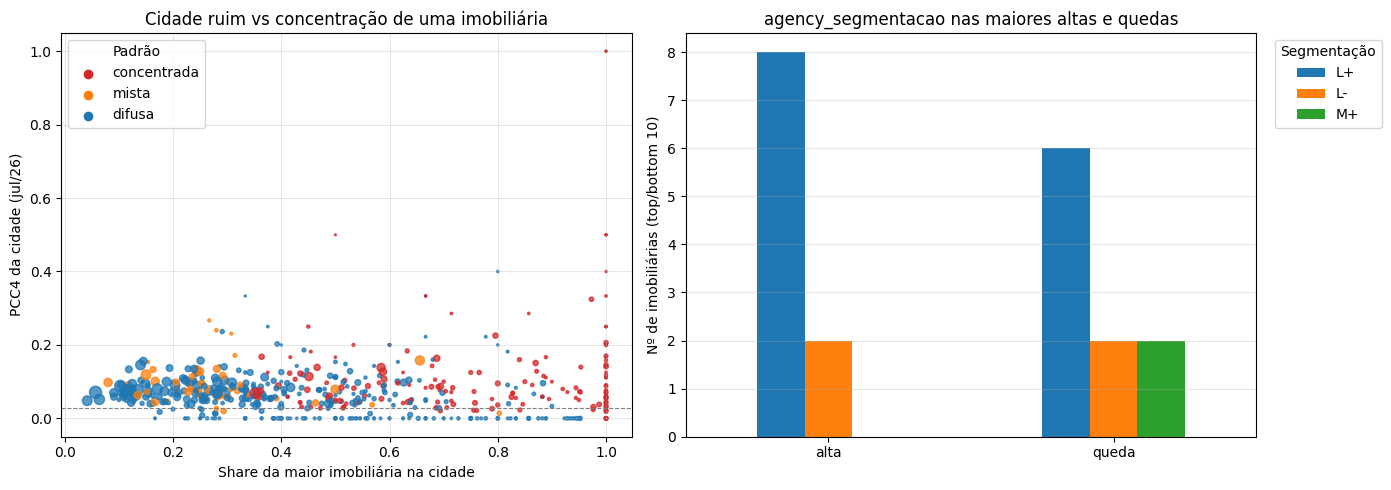

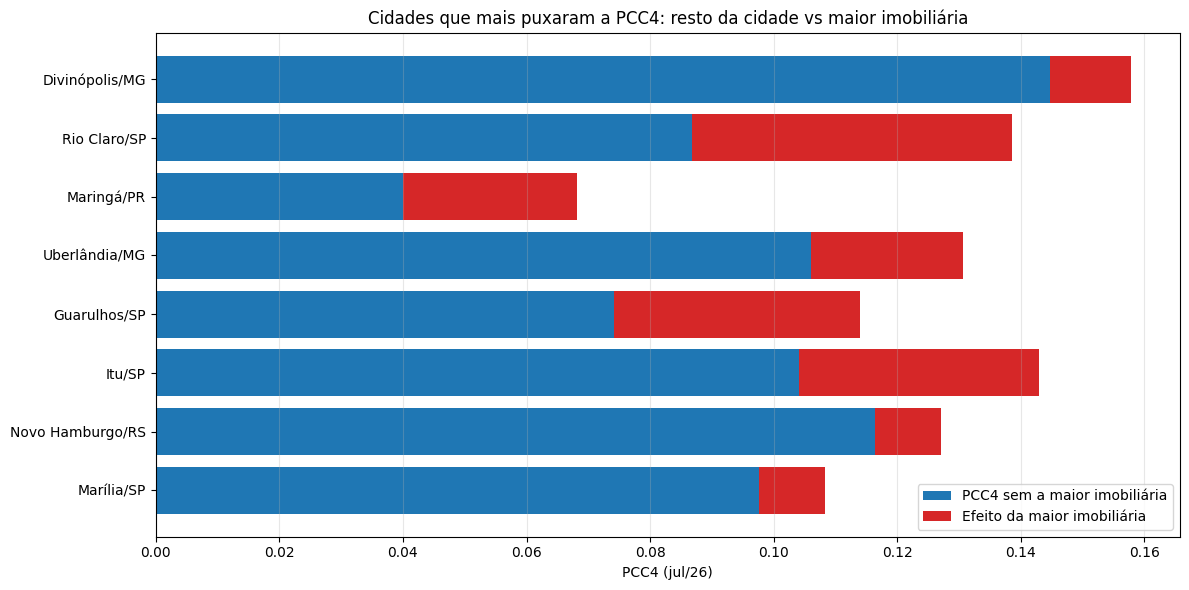

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pattern_colors = {
    "concentrada": "#d62728",
    "mista": "#ff7f0e",
    "difusa": "#1f77b4",
    "indefinida": "0.6",
}
colors = city_last["city_pattern"].map(pattern_colors)

ax = axes[0]
ax.scatter(
    city_last["share_top"],
    city_last["pcc_city"],
    s=np.sqrt(city_last["n_obs"].clip(1)) * 1.2,
    c=colors,
    alpha=0.75,
)
ax.axhline(city_last["pcc_city"].median(), color="0.5", linestyle="--", linewidth=0.8)
ax.set_xlabel("Share da maior imobiliária na cidade")
ax.set_ylabel("PCC4 da cidade (jul/26)")
ax.set_title("Cidade ruim vs concentração de uma imobiliária")
ax.grid(True, alpha=0.3)
for pattern, color in pattern_colors.items():
    if pattern in set(city_last["city_pattern"]):
        ax.scatter([], [], color=color, label=pattern)
ax.legend(title="Padrão")

ax = axes[1]
seg_plot = pd.concat(
    [agency_up.assign(lado="alta"), agency_down.assign(lado="queda")]
)
seg_count = (
    seg_plot.groupby(["lado", "agency_segmentacao"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reindex(["alta", "queda"])
)
seg_count.plot(kind="bar", ax=ax, rot=0)
ax.set_title("agency_segmentacao nas maiores altas e quedas")
ax.set_ylabel("Nº de imobiliárias (top/bottom 10)")
ax.set_xlabel("")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Segmentação", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

focus = city_last.nlargest(8, "d_contrib_city")
fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(focus))
ax.barh(y, focus["pcc_ex_top"], color="#1f77b4", label="PCC4 sem a maior imobiliária")
ax.barh(
    y,
    focus["gap_top"].fillna(0),
    left=focus["pcc_ex_top"].fillna(focus["pcc_city"]),
    color="#d62728",
    label="Efeito da maior imobiliária",
)
ax.set_yticks(y, focus["city_label"].fillna(focus["id_cidade_ibge"].astype(str)))
ax.invert_yaxis()
ax.set_xlabel("PCC4 (jul/26)")
ax.set_title("Cidades que mais puxaram a PCC4: resto da cidade vs maior imobiliária")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()


In [69]:
df_sim_ctr[["id_cidade_ibge", "id_imobiliaria", "agency_segmentacao"]]

,id_cidade_ibge,id_imobiliaria,agency_segmentacao
0,3501608,33400,Corretor
1,4119905,30599,M+
2,3526902,4549,L+
3,3538709,15846,L-
4,3501608,2863,M+
...,...,...,...
2701156,4314902,11153,L+
2701157,4107652,10417,M+
2701158,4311403,3933,M-
2701159,4105508,19049,M+


## Ordenação PCC_2m / PCC_3m por faixas de PC_Cidades

PC da cidade (`city_pc4_mais_100_contratos__pc_categorias`) da tabela Blend3, quebrada em tercis (`qcut`). Cidades sem 100+ contratos ficam na faixa `sem PC (não 100+)`.

O `mean()` de `pcc_2m` / `pcc_3m` já ignora imaturos e não ativados. Espera-se ordenação crescente: faixa baixa < média < alta.

In [70]:
project_id = 'loft-dl-datascience'

query_city = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
'''

df_city = pd.read_gbq(query_city, project_id=project_id)
df_city

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,3522307,0.028125
1,2025-12-01,5003702,0.030303
2,2025-12-01,4216206,0.033113
3,2025-12-01,5008305,0.036496
4,2025-12-01,3500105,0.039216
...,...,...,...
1709,2026-08-01,3533908,0.180328
1710,2026-08-01,3122306,0.183087
1711,2026-08-01,2800308,0.204589
1712,2026-08-01,4313300,0.207407


In [71]:
df_sim_ctr_blend3 = df_sim_ctr[df_sim_ctr["bureau_nm_ajust"] == "BLEND3"].copy()

df_sim_ctr_blend3["mes_referencia"] = (
    pd.to_datetime(df_sim_ctr_blend3["requested_at"])
    .dt.to_period("M")
    .dt.to_timestamp()
)
df_sim_ctr_blend3["id_cidade_ibge"] = pd.to_numeric(
    df_sim_ctr_blend3["id_cidade_ibge"], errors="coerce"
).astype("Int64")

df_city_m = df_city.copy()
df_city_m["mes_referencia"] = pd.to_datetime(df_city_m["mes_referencia"]).dt.normalize()
df_city_m["id_cidade_ibge"] = pd.to_numeric(
    df_city_m["id_cidade_ibge"], errors="coerce"
).astype("Int64")

df_blend3 = df_sim_ctr_blend3.merge(
    df_city_m,
    on=["mes_referencia", "id_cidade_ibge"],
    how="left",
)
print("n Blend3:", len(df_blend3))
print("% sem PC cidade:", df_blend3["city_pc4_mais_100_contratos__pc_categorias"].isna().mean())
df_blend3

n Blend3: 435934
% sem PC cidade: 0.12247037395569053


,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,pcc_2m,pcc_3m,pcc_4m,pd_2m,pd_3m,pd_4m,safra,safra_dt,mes_referencia,city_pc4_mais_100_contratos__pc_categorias
0,4257621,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.063401
1,4256749,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.056229
2,4257855,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.087515
3,4258444,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.129032
4,4260730,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.087515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435929,3987722,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Smart,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-04,2026-04-01,2026-04-01,NaN
435930,3988952,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Smart,...,0,0,0,0,0,0,2026-04,2026-04-01,2026-04-01,0.151316
435931,3989277,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Smart,...,0,0,0,0,0,0,2026-04,2026-04-01,2026-04-01,0.104099
435932,3988471,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Up,...,0,1,1,0,0,0,2026-04,2026-04-01,2026-04-01,0.057831


In [72]:
PC_COL = "city_pc4_mais_100_contratos__pc_categorias"

df_eval = df_blend3.copy()

pc_obs = df_eval[PC_COL].notna()
df_eval.loc[pc_obs, "faixa_city_pc4"] = pd.qcut(
    df_eval.loc[pc_obs, PC_COL],
    q=3,
    duplicates="drop",
).astype(str)
df_eval["faixa_city_pc4"] = df_eval["faixa_city_pc4"].fillna("sem PC (não 100+)")

resumo_faixa = (
    df_eval.groupby("faixa_city_pc4", dropna=False)
    .agg(
        n=("contract_id", "size"),
        n_cidades=("id_cidade_ibge", "nunique"),
        pc_city_p50=(PC_COL, "median"),
        n_pcc2=("pcc_2m", "count"),
        pcc_2m=("pcc_2m", "mean"),
        n_pcc3=("pcc_3m", "count"),
        pcc_3m=("pcc_3m", "mean"),
    )
    .reset_index()
)

geral = pd.DataFrame(
    {
        "faixa_city_pc4": ["total"],
        "n": [len(df_eval)],
        "n_cidades": [df_eval["id_cidade_ibge"].nunique()],
        "pc_city_p50": [df_eval[PC_COL].median()],
        "n_pcc2": [df_eval["pcc_2m"].count()],
        "pcc_2m": [df_eval["pcc_2m"].mean()],
        "n_pcc3": [df_eval["pcc_3m"].count()],
        "pcc_3m": [df_eval["pcc_3m"].mean()],
    }
)

resumo_faixa = pd.concat([resumo_faixa, geral], ignore_index=True)
resumo_faixa

,faixa_city_pc4,n,n_cidades,pc_city_p50,n_pcc2,pcc_2m,n_pcc3,pcc_3m
0,"(0.00658, 0.0866]",128904,127,0.074244,14159,0.034254,9033,0.06598
1,"(0.0866, 0.116]",126710,99,0.098206,11206,0.044173,7494,0.07913
2,"(0.116, 0.267]",126931,79,0.139321,9631,0.055134,6462,0.093315
3,sem PC (não 100+),53389,1028,NaN,5310,0.037665,3487,0.064239
4,total,435934,1199,0.098166,40306,0.04245,26476,0.076144


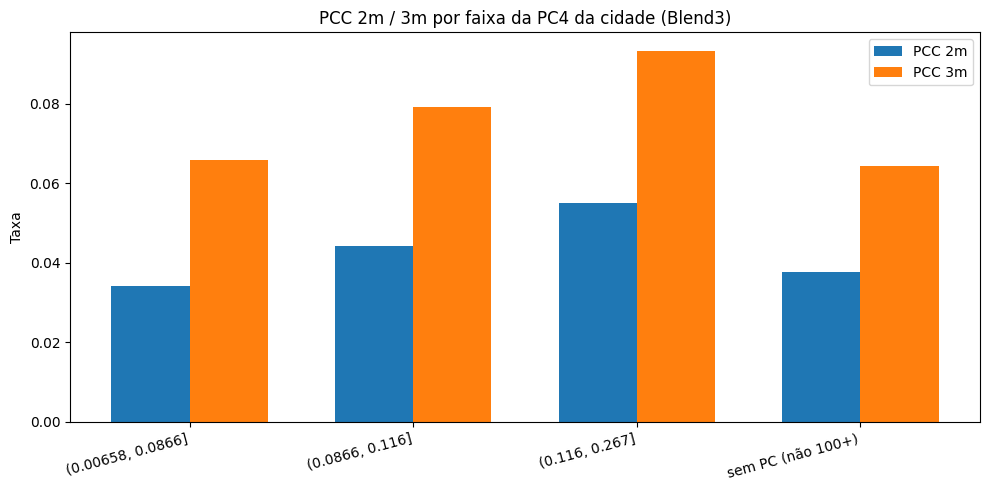

In [73]:
plot_df = resumo_faixa[resumo_faixa["faixa_city_pc4"] != "total"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
ax.bar(x - w / 2, plot_df["pcc_2m"], w, label="PCC 2m")
ax.bar(x + w / 2, plot_df["pcc_3m"], w, label="PCC 3m")
ax.set_xticks(x, plot_df["faixa_city_pc4"], rotation=15, ha="right")
ax.set_ylabel("Taxa")
ax.set_title("PCC 2m / 3m por faixa da PC4 da cidade (Blend3)")
ax.legend()
plt.tight_layout()
plt.show()

### Sem fallback

Mesma ordenação excluindo `is_fallback == 1` (BVS/HVA no Blend3). Usando blend_regressao_predict_nr não nulo!

In [89]:
df_eval_nf = df_eval[df_eval["blend_regressao_predict_nr"].notna()].copy()

resumo_faixa_nf = (
    df_eval_nf.groupby("faixa_city_pc4", dropna=False)
    .agg(
        n=("contract_id", "size"),
        n_elegiveis=("lead_elegivel", "sum"),
        n_cidades=("id_cidade_ibge", "nunique"),
        pc_city_p50=(PC_COL, "median"),
        n_pcc2=("pcc_2m", "count"),
        pcc_2m=("pcc_2m", "mean"),
        n_pcc3=("pcc_3m", "count"),
        pcc_3m=("pcc_3m", "mean"),
    )
    .reset_index()
)

geral_nf = pd.DataFrame(
    {
        "faixa_city_pc4": ["total"],
        "n": [len(df_eval_nf)],
        "n_elegiveis": [df_eval_nf["lead_elegivel"].sum()],
        "n_cidades": [df_eval_nf["id_cidade_ibge"].nunique()],
        "pc_city_p50": [df_eval_nf[PC_COL].median()],
        "n_pcc2": [df_eval_nf["pcc_2m"].count()],
        "pcc_2m": [df_eval_nf["pcc_2m"].mean()],
        "n_pcc3": [df_eval_nf["pcc_3m"].count()],
        "pcc_3m": [df_eval_nf["pcc_3m"].mean()],
    }
)

resumo_faixa_nf = pd.concat([resumo_faixa_nf, geral_nf], ignore_index=True)
resumo_faixa_nf

,faixa_city_pc4,n,n_elegiveis,n_cidades,pc_city_p50,n_pcc2,pcc_2m,n_pcc3,pcc_3m
0,"(0.00658, 0.0866]",108567,89731,127,0.073999,14116,0.034358,9000,0.066222
1,"(0.0866, 0.116]",102642,77253,99,0.098206,11165,0.044245,7462,0.079335
2,"(0.116, 0.267]",102562,63096,79,0.139321,9594,0.05493,6433,0.093114
3,sem PC (não 100+),43964,35000,989,NaN,5285,0.037843,3466,0.064628
4,total,357735,265080,1162,0.097576,40160,0.04248,26361,0.076287


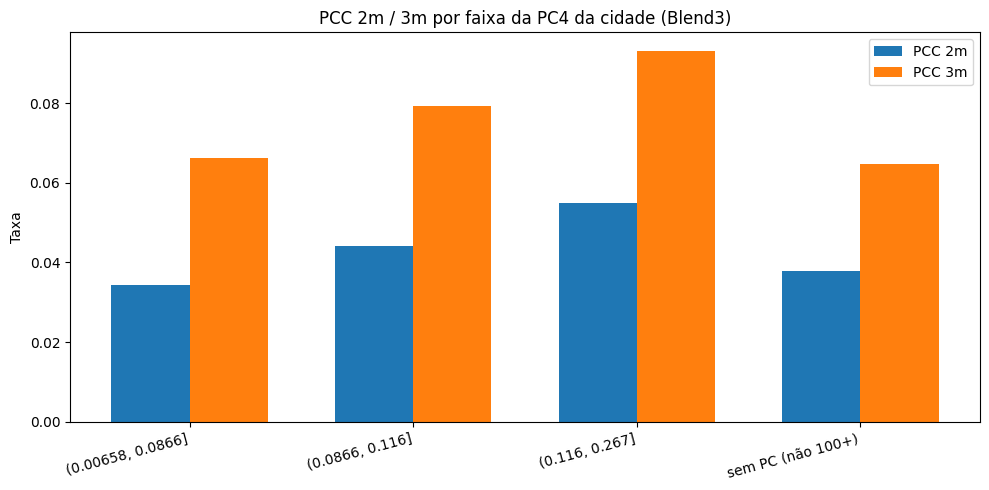

In [84]:
plot_df = resumo_faixa_nf[resumo_faixa_nf["faixa_city_pc4"] != "total"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
ax.bar(x - w / 2, plot_df["pcc_2m"], w, label="PCC 2m")
ax.bar(x + w / 2, plot_df["pcc_3m"], w, label="PCC 3m")
ax.set_xticks(x, plot_df["faixa_city_pc4"], rotation=15, ha="right")
ax.set_ylabel("Taxa")
ax.set_title("PCC 2m / 3m por faixa da PC4 da cidade (Blend3)")
ax.legend()
plt.tight_layout()
plt.show()

## Sem Fallback e sem E

In [92]:
df_eval_nf = df_eval[((df_eval["blend_regressao_predict_nr"].notna())&(df_eval["rating_score_ds"]!="E"))].copy()

resumo_faixa_nf = (
    df_eval_nf.groupby("faixa_city_pc4", dropna=False)
    .agg(
        n=("contract_id", "size"),
        n_elegiveis=("lead_elegivel", "sum"),
        n_cidades=("id_cidade_ibge", "nunique"),
        pc_city_p50=(PC_COL, "median"),
        n_pcc2=("pcc_2m", "count"),
        pcc_2m=("pcc_2m", "mean"),
        n_pcc3=("pcc_3m", "count"),
        pcc_3m=("pcc_3m", "mean"),
    )
    .reset_index()
)

geral_nf = pd.DataFrame(
    {
        "faixa_city_pc4": ["total"],
        "n": [len(df_eval_nf)],
        "n_elegiveis": [df_eval_nf["lead_elegivel"].sum()],
        "n_cidades": [df_eval_nf["id_cidade_ibge"].nunique()],
        "pc_city_p50": [df_eval_nf[PC_COL].median()],
        "n_pcc2": [df_eval_nf["pcc_2m"].count()],
        "pcc_2m": [df_eval_nf["pcc_2m"].mean()],
        "n_pcc3": [df_eval_nf["pcc_3m"].count()],
        "pcc_3m": [df_eval_nf["pcc_3m"].mean()],
    }
)

resumo_faixa_nf = pd.concat([resumo_faixa_nf, geral_nf], ignore_index=True)
resumo_faixa_nf

,faixa_city_pc4,n,n_elegiveis,n_cidades,pc_city_p50,n_pcc2,pcc_2m,n_pcc3,pcc_3m
0,"(0.00658, 0.0866]",84216,82876,127,0.072993,13634,0.031465,8683,0.060924
1,"(0.0866, 0.116]",69210,68089,99,0.097576,10483,0.03892,7026,0.070168
2,"(0.116, 0.267]",55799,54749,79,0.136444,8892,0.050832,6004,0.085443
3,sem PC (não 100+),31130,30724,930,NaN,4918,0.029687,3240,0.054938
4,total,240355,236438,1103,0.091747,37927,0.037836,24953,0.068649


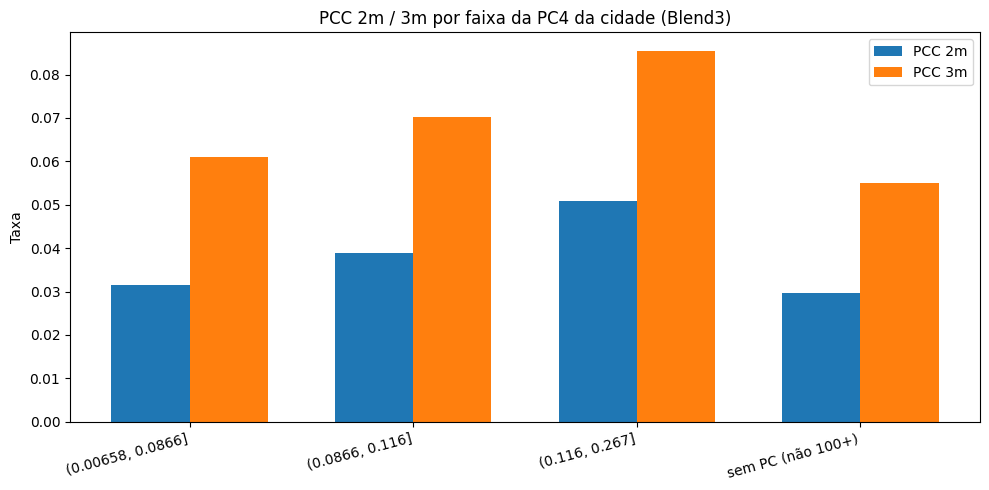

In [93]:
plot_df = resumo_faixa_nf[resumo_faixa_nf["faixa_city_pc4"] != "total"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
ax.bar(x - w / 2, plot_df["pcc_2m"], w, label="PCC 2m")
ax.bar(x + w / 2, plot_df["pcc_3m"], w, label="PCC 3m")
ax.set_xticks(x, plot_df["faixa_city_pc4"], rotation=15, ha="right")
ax.set_ylabel("Taxa")
ax.set_title("PCC 2m / 3m por faixa da PC4 da cidade (Blend3)")
ax.legend()
plt.tight_layout()
plt.show()

In [100]:
df_eval_nf

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,pcc_4m,pd_2m,pd_3m,pd_4m,safra,safra_dt,mes_referencia,city_pc4_mais_100_contratos__pc_categorias,faixa_city_pc4,safra_ativação
0,4257621,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.063401,"(0.00658, 0.0866]",NaT
1,4256749,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,None,...,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.056229,"(0.00658, 0.0866]",NaT
2,4257855,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.087515,"(0.0866, 0.116]",NaT
23,4257217,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.136444,"(0.116, 0.267]",NaT
24,4259054,2026-06-16,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,<NA>,<NA>,<NA>,<NA>,2026-06,2026-06-01,2026-06-01,0.087515,"(0.0866, 0.116]",NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435929,3987722,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Smart,...,<NA>,<NA>,<NA>,<NA>,2026-04,2026-04-01,2026-04-01,NaN,sem PC (não 100+),NaT
435930,3988952,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Smart,...,0,0,0,0,2026-04,2026-04-01,2026-04-01,0.151316,"(0.116, 0.267]",2026-04
435931,3989277,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Smart,...,0,0,0,0,2026-04,2026-04-01,2026-04-01,0.104099,"(0.0866, 0.116]",2026-04
435932,3988471,2026-04-07,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,Up,...,1,0,0,0,2026-04,2026-04-01,2026-04-01,0.057831,"(0.00658, 0.0866]",2026-04


In [101]:
df_eval_nf["safra_ativação"] = (
    pd.to_datetime(df_eval_nf["activated_at"], utc=True)
    .dt.tz_localize(None)
    .dt.to_period("M")
    .astype(str)
)

df_plot = df_eval_nf[df_eval_nf["safra"].isin(["2026-04", "2026-05"])].copy()
print(df_plot["safra"].value_counts(dropna=False).sort_index())

safra
2026-04    50652
2026-05    51906
Name: count, dtype: int64


In [102]:
resumo_faixa_nf = (
    df_plot.groupby("faixa_city_pc4", dropna=False)
    .agg(
        n=("contract_id", "size"),
        n_elegiveis=("lead_elegivel", "sum"),
        n_cidades=("id_cidade_ibge", "nunique"),
        pc_city_p50=(PC_COL, "median"),
        n_pcc2=("pcc_2m", "count"),
        pcc_2m=("pcc_2m", "mean"),
        n_pcc3=("pcc_3m", "count"),
        pcc_3m=("pcc_3m", "mean"),
    )
    .reset_index()
)

geral_nf = pd.DataFrame(
    {
        "faixa_city_pc4": ["total"],
        "n": [len(df_plot)],
        "n_elegiveis": [df_plot["lead_elegivel"].sum()],
        "n_cidades": [df_plot["id_cidade_ibge"].nunique()],
        "pc_city_p50": [df_plot[PC_COL].median()],
        "n_pcc2": [df_plot["pcc_2m"].count()],
        "pcc_2m": [df_plot["pcc_2m"].mean()],
        "n_pcc3": [df_plot["pcc_3m"].count()],
        "pcc_3m": [df_plot["pcc_3m"].mean()],
    }
)

resumo_faixa_nf = pd.concat([resumo_faixa_nf, geral_nf], ignore_index=True)
resumo_faixa_nf

,faixa_city_pc4,n,n_elegiveis,n_cidades,pc_city_p50,n_pcc2,pcc_2m,n_pcc3,pcc_3m
0,"(0.00658, 0.0866]",35714,35179,97,0.071253,9098,0.034183,8580,0.061072
1,"(0.0866, 0.116]",28821,28362,69,0.097403,7237,0.042006,6914,0.070437
2,"(0.116, 0.267]",24621,24130,63,0.140000,6204,0.054965,5932,0.085469
3,sem PC (não 100+),13402,13232,723,NaN,3378,0.033748,3186,0.055869
4,total,102558,100903,913,0.093694,25917,0.041286,24612,0.068909


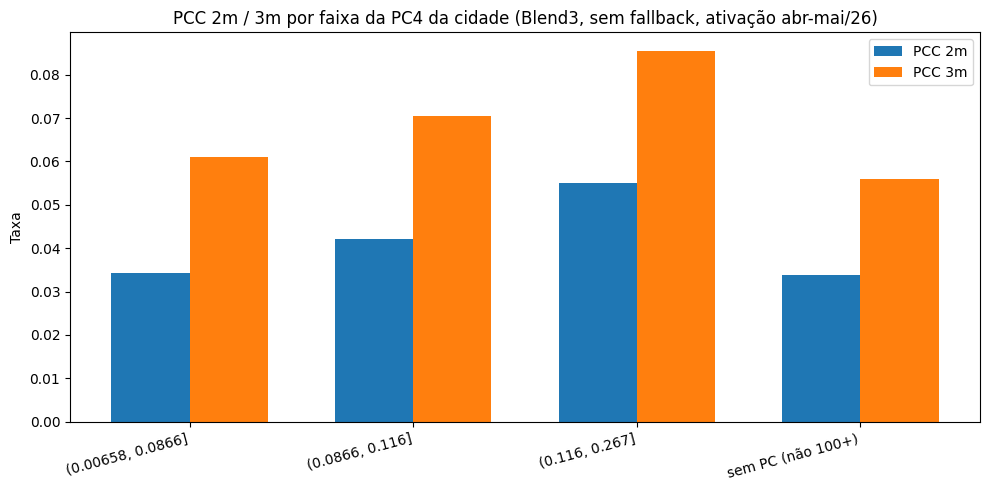

In [103]:
plot_df = resumo_faixa_nf[resumo_faixa_nf["faixa_city_pc4"] != "total"].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
ax.bar(x - w / 2, plot_df["pcc_2m"], w, label="PCC 2m")
ax.bar(x + w / 2, plot_df["pcc_3m"], w, label="PCC 3m")
ax.set_xticks(x, plot_df["faixa_city_pc4"], rotation=15, ha="right")
ax.set_ylabel("Taxa")
ax.set_title("PCC 2m / 3m por faixa da PC4 da cidade (Blend3, sem fallback, ativação abr-mai/26)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_eval_nf

In [85]:
df_sim_ctr.columns.to_list()

['contract_id',
 'requested_at',
 'tipo',
 'tipo_contrato',
 'rule',
 'bureau_nm',
 'modeloBlend',
 'approved_products',
 'flag_pop32',
 'product_nm',
 'bureau_nm_ajust',
 'is_fallback',
 'id_imobiliaria',
 'id_cidade_ibge',
 'imovel_cidade',
 'imovel_uf',
 'agency_segmentacao',
 'lead_elegivel',
 'proposta_iniciada',
 'proposta_enviada',
 'proposta_aprovada',
 'proposta_ativada',
 'is_activeted',
 'activated_at',
 'aprovado_motor_mesa',
 'rating_score_ds',
 'is_single_proponent',
 'blend_regressao_predict_nr',
 'is_activeted_1',
 'time2requested',
 'time2def_pc',
 'time2def_pcc',
 'time2def_pd',
 'first_comunicacao_date',
 'first_competencia_date',
 'first_payment_date',
 'pc_2m',
 'pc_3m',
 'pc_4m',
 'pcc_2m',
 'pcc_3m',
 'pcc_4m',
 'pd_2m',
 'pd_3m',
 'pd_4m',
 'safra',
 'safra_dt']

In [80]:
df_sim_ctr["blend_regressao_predict_nr"].isna().sum(), df_sim_ctr["blend_regressao_predict_nr"].notna().sum()

(np.int64(883086), np.int64(1818075))

In [91]:
df_sim_ctr[df_sim_ctr["blend_regressao_predict_nr"].notna()].groupby("rating_score_ds").size()

rating_score_ds
A     231083
A+      3021
B     360432
B+      6310
C     395308
D     196715
D+      3364
E     621842
dtype: int64

In [82]:
df_sim_ctr[((df_sim_ctr["is_fallback"]==1)&(df_sim_ctr["blend_regressao_predict_nr"].notna()))].groupby("bureau_nm_ajust").size()

Series([], dtype: int64)

In [94]:
df_eval_nf[['lead_elegivel', 'proposta_iniciada', 'proposta_enviada',
       'proposta_aprovada', 'proposta_ativada', 'is_activeted', 'activated_at',]]

,lead_elegivel,proposta_iniciada,proposta_enviada,proposta_aprovada,proposta_ativada,is_activeted,activated_at
0,True,False,False,False,False,False,NaT
1,True,False,False,False,False,False,NaT
2,True,True,False,False,False,False,NaT
23,True,False,False,False,False,False,NaT
24,True,False,False,False,False,False,NaT
...,...,...,...,...,...,...,...
435929,True,True,True,False,False,False,NaT
435930,True,True,True,True,True,True,2026-04-08 00:00:00+00:00
435931,True,True,True,True,True,True,2026-04-07 00:00:00+00:00
435932,True,True,True,True,True,True,2026-04-07 00:00:00+00:00
